In [1]:
!pip install pyotp mplfinance pandas_ta fyers_apiv3 pygame stable-baselines3 gymnasium shimmy optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.1/115.1 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.8/171.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 7.0 MB/s eta 0:00:00
 

In [1]:
import requests
import base64
from datetime import datetime, timedelta, date
from datetime import time as dt_time
import time
import threading
import pyotp
from pytz import timezone
import pandas as pd
import numpy as np
from urllib.parse import urlparse, parse_qs
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import mplfinance as mpf
import pandas_ta as ta
import pygame
import os
import pytz
import json
import re
import random
import pickle

import gymnasium as gym
from gymnasium import spaces
from IPython.display import display, clear_output
from tqdm.notebook import tqdm

from fyers_apiv3 import fyersModel
from fyers_apiv3.FyersWebsocket import data_ws

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Dropout, Attention, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.callbacks import Callback, ModelCheckpoint
from scipy.signal import argrelextrema
import tensorflow as tf
from collections import deque
from tensorflow import keras
from tensorflow.keras import layers, optimizers, models
from scipy.signal import find_peaks

pygame 2.6.1 (SDL 2.28.4, Python 3.11.11)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
def get_index_symbol_and_quantity(index):

    # Dictionary mapping index name to index symbols
    index_symbols = {
        'Bankex': 'BSE:BANKEX-INDEX',
        'Finnifty': 'NSE:FINNIFTY-INDEX',
        'Bank Nifty': 'NSE:NIFTYBANK-INDEX',
        'Nifty': 'NSE:NIFTY50-INDEX',
        'Sensex': 'BSE:SENSEX-INDEX'
    }

    # Determine the index symbol for the given index
    index_symbol = index_symbols.get(index, 'Invalid Index')

    # Determine the quantity based on the index symbol
    if index_symbol == "NSE:NIFTY50-INDEX":
        quantity = 25  # 25 is one lot for Nifty
    elif index_symbol == "NSE:NIFTYBANK-INDEX":
        quantity = 15  # 15 is one lot for Bank Nifty
    elif index_symbol == "NSE:FINNIFTY-INDEX":
        quantity = 40  # 40 is one lot for Finnifty
    elif index_symbol == "BSE:SENSEX-INDEX":
        quantity = 20  # 20 is two lot for Sensex
    elif index_symbol == "BSE:BANKEX-INDEX":
        quantity = 15  # 15 is one lot for Bankex
    else:
        quantity = 0  # Default value if none of the conditions match

    return index_symbol, quantity

In [3]:
app_id = "TS79V3NXK1-100"
secret_key = "KQCPB0FJ74"
redirect_uri = "https://google.com"
fyers_user = "XM22383"
fyers_pin = "4628"
fyers_totp = "EAQD6K4IUYOEGPJNVE6BMPTUSDCWIOHW"
response_type = "code"
state = "sample_state"
grant_type = "authorization_code"

fyers = None
fyers_socket = None

index_symbol, quantity = get_index_symbol_and_quantity("Bank Nifty")

interval_minutes = 2 # Set the interval to 1, 5, or 15 minutes

ist_timezone = pytz.timezone("Asia/Kolkata")

# Initialize the mixer
#pygame.mixer.init()

# Load the sound file
#pygame.mixer.music.load('sounds/alert.mp3')

#Variables
ce_ltp = 0
pe_ltp = 0
index_ltp = 0
buy_sell_checked = False
ce_strike = None
pe_strike = None
ce_symbol = None
pe_symbol = None

target = 80
trailing_sl = 40

brokerage = 100

fixed_ltp = 0
fixed_index_ltp = 0
prev_ltp = 0
target_inside = 0
target_index_inside = 0
trailing_sl_inside = 0
trailing_index_inside = 0

active_order = False

sl_hit_condition = False
total_loss = 0
total_profit = 0
overall_win = 0
overall_loss = 0
total_points = 0

unsubscribe_done = False

active_order_sleep = 1

In [4]:
session = fyersModel.SessionModel(
    client_id=app_id,
    secret_key=secret_key,
    redirect_uri=redirect_uri,
    response_type=response_type,
    grant_type=grant_type
)

def getEncodedString(string):
    string = str(string)
    base64_bytes = base64.b64encode(string.encode("ascii"))
    return base64_bytes.decode("ascii")

if session is not None:
    session.generate_authcode()

    url_send_login_otp = "https://api-t2.fyers.in/vagator/v2/send_login_otp_v2"
    res = requests.post(url=url_send_login_otp, json={"fy_id": getEncodedString(fyers_user), "app_id": "2"}).json()

    if datetime.now().second % 30 > 27:
        time.sleep(5)

    url_verify_otp = "https://api-t2.fyers.in/vagator/v2/verify_otp"
    res2 = requests.post(url=url_verify_otp, json={"request_key": res["request_key"], "otp": pyotp.TOTP(fyers_totp).now()}).json()

    ses = requests.Session()
    url_verify_otp2 = "https://api-t2.fyers.in/vagator/v2/verify_pin_v2"
    payload2 = {"request_key": res2["request_key"], "identity_type": "pin", "identifier": getEncodedString(fyers_pin)}
    res3 = ses.post(url=url_verify_otp2, json=payload2).json()

    ses.headers.update({'authorization': f"Bearer {res3['data']['access_token']}"})

    tokenurl = "https://api-t1.fyers.in/api/v3/token"
    payload3 = {
        "fyers_id": fyers_user,
        "app_id": app_id[:-4],
        "redirect_uri": redirect_uri,
        "appType": "100",
        "code_challenge": "",
        "state": "None",
        "scope": "",
        "nonce": "",
        "response_type": "code",
        "create_cookie": True
    }

    res3 = ses.post(url=tokenurl, json=payload3).json()

    url = res3['Url']
    parsed = urlparse(url)
    auth_code = parse_qs(parsed.query)['auth_code'][0]

    session.set_token(auth_code)

    auth_response = session.generate_token()
    access_token = auth_response["access_token"]

    fyers = fyersModel.FyersModel(client_id=app_id, token=access_token)

    ws_token = app_id + ":" + access_token
    fyers_socket = data_ws.FyersDataSocket(access_token=ws_token, log_path="")

pd.DataFrame(fyers.get_profile())

,s,code,message,data
fy_id,ok,200,,XM22383
name,ok,200,,MARSHAL TUDU
image,ok,200,,https://myaccount-docs-prod.fyers.in/Profile_P...
display_name,ok,200,,None
pin_change_date,ok,200,,25-09-2023 17:16:16
email_id,ok,200,,iammarshal22@gmail.com
pwd_change_date,ok,200,,01-06-2022 20:36:31
PAN,ok,200,,---------
mobile_number,ok,200,,8458060663
totp,ok,200,,True


In [5]:
def fetch_candle_data(number):
    while True:
        try:
            today = date.today()
            yesterday = today - timedelta(number)

            data = {
                "symbol": index_symbol,
                "resolution": interval_minutes,
                "date_format": "1",
                "range_from": yesterday,
                "range_to": today,
                "cont_flag": "1"
            }

            result = fyers.history(data=data)

            if result is not None:
                train_df = pd.DataFrame(result['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])
                return train_df
        except Exception as e:
            print(f"Error fetching Candle Data: {e}")
            time.sleep(active_order_sleep)

In [6]:
def fetch_train_candle_data(days_count):
    train_df = pd.DataFrame()

    while True:
        try:
            date_increment = 100
            for i in range(days_count):
                today = date.today() - timedelta(date_increment)
                yesterday = today - timedelta(100)

                data = {
                    "symbol": index_symbol,
                    "resolution": interval_minutes,
                    "date_format": "1",
                    "range_from": yesterday,
                    "range_to": today,
                    "cont_flag": "1"
                }

                result = fyers.history(data=data)

                if result is not None:
                    temp_df = pd.DataFrame(result['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])
                    train_df = pd.concat([temp_df, train_df], ignore_index=True)

                date_increment += 100

            if train_df is not None:
                return train_df

        except Exception as e:
            print(f"Error fetching Candle Data: {e}")
            time.sleep(active_order_sleep)

In [20]:
train_df = fetch_candle_data(100)

#train_df = fetch_train_candle_data(10)

print(len(train_df))

train_df = train_df.drop_duplicates(subset='datetime', keep='first')

print(len(train_df))

12819
12819


In [32]:
class DataProcessor:
    def __init__(self, df, indicator_length=14, live_processing=False):
        self.df = df.copy()
        self.indicator_length = indicator_length
        self.live_processing = live_processing

    def preprocess_datetime(self):
        ist = timezone('Asia/Kolkata')
        self.df['datetime'] = pd.to_datetime(self.df['datetime'], unit='s')
        self.df['datetime'] = (
            self.df['datetime']
            .dt.tz_localize('UTC')
            .dt.tz_convert(ist)
            .dt.tz_localize(None)
        )

        if self.df['datetime'].duplicated().any() or self.df['datetime'].isnull().any():
            raise ValueError("The 'datetime' column contains duplicates or missing values.")

        self.df.set_index(self.df['datetime'], inplace=True)
        self.df.drop(['datetime'], axis=1, inplace=True, errors='ignore')
        return self

    def clean_data(self):
        if 'volume' in self.df.columns:
            if self.df['volume'].isnull().any() or (self.df['volume'] == 0).any():
                self.df.drop(['volume'], axis=1, inplace=True, errors='ignore')
        return self

    def add_price_action_features(self):
        # Basic price action features
        self.df['hl_range'] = self.df['high'] - self.df['low']
        self.df['cl_position'] = (self.df['close'] - self.df['low']) / self.df['hl_range']
        self.df['oc_change'] = self.df['close'] - self.df['open']

        # Calculate ATR - base for our dynamic targets
        self.df['atr'] = ta.atr(self.df['high'], self.df['low'], self.df['close'], length=self.indicator_length)

        # Add EMAs of various lengths
        ema_periods = [5, 10, 21, 50, 100, 200]
        for period in ema_periods:
            self.df[f'ema_{period}'] = ta.ema(self.df['close'], length=period)

        # Add EMA slopes (momentum)
        for period in ema_periods:
            self.df[f'ema_{period}_slope'] = self.df[f'ema_{period}'].diff(3) / self.df[f'ema_{period}'].shift(3) * 100

        # Add EMA distances (relative position)
        self.df['ema_5_21_dist'] = (self.df['ema_5'] - self.df['ema_21']) / self.df['ema_21'] * 100
        self.df['ema_21_50_dist'] = (self.df['ema_21'] - self.df['ema_50']) / self.df['ema_50'] * 100

        # Calculate trend strength (will be used for dynamic targets)
        self.df['trend_strength'] = abs(self.df['ema_5_21_dist']) + abs(self.df['ema_21_50_dist'])

        return self

    def detect_market_condition(self):
        # Market condition based on EMA alignments and slopes
        # 1: Strong Bullish, 2: Moderate Bullish, 3: Sideways, 4: Moderate Bearish, 5: Strong Bearish
        self.df['market_condition'] = 3  # Default to sideways

        # Strong Bullish Conditions
        strong_bullish = (
            (self.df['ema_5'] > self.df['ema_21']) &
            (self.df['ema_21'] > self.df['ema_50']) &
            (self.df['ema_5_21_dist'] > 0.3) &
            (self.df['ema_5_slope'] > 0.1)
        )

        # Strong Bearish Conditions
        strong_bearish = (
            (self.df['ema_5'] < self.df['ema_21']) &
            (self.df['ema_21'] < self.df['ema_50']) &
            (self.df['ema_5_21_dist'] < -0.3) &
            (self.df['ema_5_slope'] < -0.1)
        )

        # Moderate Bullish Conditions
        moderate_bullish = (
            (self.df['ema_5'] > self.df['ema_21']) &
            (self.df['ema_5_slope'] > 0)
        )

        # Moderate Bearish Conditions
        moderate_bearish = (
            (self.df['ema_5'] < self.df['ema_21']) &
            (self.df['ema_5_slope'] < 0)
        )

        self.df.loc[strong_bullish, 'market_condition'] = 1
        self.df.loc[moderate_bullish & ~strong_bullish, 'market_condition'] = 2
        self.df.loc[moderate_bearish & ~strong_bearish, 'market_condition'] = 4
        self.df.loc[strong_bearish, 'market_condition'] = 5

        # Set dynamic risk-reward based on market condition and trend strength
        self.df['rr_ratio'] = 1.5  # Default RR ratio

        # Adjust RR ratio based on market condition and trend strength
        # Strong trends get higher targets
        self.df.loc[self.df['market_condition'].isin([1, 5]), 'rr_ratio'] = 2.5
        # Moderate trends get medium targets
        self.df.loc[self.df['market_condition'].isin([2, 4]), 'rr_ratio'] = 2.0
        # Sideways gets conservative targets
        self.df.loc[self.df['market_condition'] == 3, 'rr_ratio'] = 1.5

        # Further adjust based on trend strength
        self.df['rr_ratio'] = self.df['rr_ratio'] * (1 + self.df['trend_strength']/100)

        # Calculate dynamic target and stop-loss
        self.df['Target'] = self.df['atr'] * self.df['rr_ratio']
        self.df['Stop Loss'] = self.df['atr'] * 0.8  # Slightly tighter stop-loss

        return self

    def detect_entry_conditions(self):
        # Initialize entry condition columns
        self.df['buy_condition'] = False
        self.df['sell_condition'] = False

        # Buy Conditions - now works in all market conditions
        self.df['buy_condition'] = (
            (self.df['ema_5'] > self.df['ema_21']) &
            (self.df['ema_5_slope'] > 0)  # Just needs positive momentum
        )

        # Sell Conditions - now works in all market conditions
        self.df['sell_condition'] = (
            (self.df['ema_5'] < self.df['ema_21']) &
            (self.df['ema_5_slope'] < 0)  # Just needs negative momentum
        )

        return self

    def label_signals(self):
        self.df['Signal'] = 0
        self.df['Entry Price'] = 0.0
        self.df['Exit Price'] = 0.0

        for i in range(len(self.df)):
            if not (self.df['buy_condition'].iloc[i] or self.df['sell_condition'].iloc[i]):
                continue

            entry_price = self.df['close'].iloc[i]
            target = self.df['Target'].iloc[i]
            stop_loss = self.df['Stop Loss'].iloc[i]

            if self.df['buy_condition'].iloc[i]:
                buy_target_price = entry_price + target
                buy_sl_price = entry_price - stop_loss

                future_data = self.df.iloc[i + 1:]
                for j in range(len(future_data)):
                    future_high = future_data['high'].iloc[j]
                    future_low = future_data['low'].iloc[j]

                    if future_high >= buy_target_price:
                        self.df.at[self.df.index[i], 'Signal'] = 1
                        self.df.at[self.df.index[i], 'Entry Price'] = entry_price
                        self.df.at[self.df.index[i], 'Exit Price'] = buy_target_price
                        break
                    elif future_low <= buy_sl_price:
                        break

            elif self.df['sell_condition'].iloc[i]:
                sell_target_price = entry_price - target
                sell_sl_price = entry_price + stop_loss

                future_data = self.df.iloc[i + 1:]
                for j in range(len(future_data)):
                    future_high = future_data['high'].iloc[j]
                    future_low = future_data['low'].iloc[j]

                    if future_low <= sell_target_price:
                        self.df.at[self.df.index[i], 'Signal'] = 2
                        self.df.at[self.df.index[i], 'Entry Price'] = entry_price
                        self.df.at[self.df.index[i], 'Exit Price'] = sell_target_price
                        break
                    elif future_high >= sell_sl_price:
                        break

        return self

    def process(self):
        self.preprocess_datetime()
        self.clean_data()
        self.add_price_action_features()
        self.detect_market_condition()
        self.detect_entry_conditions()

        if self.live_processing:
            return self.finalize()

        self.label_signals()
        return self.finalize()

    def finalize(self):
        self.df = self.df[[col for col in self.df.columns if col not in ['Entry Price', 'Exit Price']]]
        self.df.dropna(inplace=True)
        feature_columns = [col for col in self.df.columns if col not in ['Entry Price', 'Exit Price']]
        self.df[feature_columns] = self.df[feature_columns].astype(float).round(2)
        self.df['Target'] = self.df['Target'].astype(float).round(2)
        self.df['Stop Loss'] = self.df['Stop Loss'].astype(float).round(2)
        self.df["Signal"] = self.df["Signal"].astype(int)
        return self


# Usage Example
data_processor = DataProcessor(train_df)
processed_df = data_processor.process().df

processed_df

,open,high,low,close,hl_range,cl_position,oc_change,atr,ema_5,ema_10,...,ema_5_21_dist,ema_21_50_dist,trend_strength,market_condition,rr_ratio,Target,Stop Loss,buy_condition,sell_condition,Signal
datetime,,,,,,,,,,,,,,,,,,,,,
2024-10-09 09:43:00,51085.75,51138.40,51084.50,51102.40,53.90,0.33,16.65,58.52,51064.17,51053.85,...,0.03,-0.00,0.03,2.0,2.00,117.07,46.81,1.0,0.0,0
2024-10-09 09:45:00,51103.25,51117.55,51047.80,51080.90,69.75,0.47,-22.35,59.32,51069.75,51058.77,...,0.04,0.00,0.04,2.0,2.00,118.68,47.46,1.0,0.0,0
2024-10-09 09:47:00,51082.60,51083.80,51043.60,51043.60,40.20,0.00,-39.00,57.95,51061.03,51056.01,...,0.02,0.00,0.02,2.0,2.00,115.93,46.36,1.0,0.0,0
2024-10-09 09:49:00,51046.95,51062.90,51027.40,51057.35,35.50,0.84,10.40,56.35,51059.80,51056.25,...,0.02,0.00,0.02,3.0,1.50,84.54,45.08,0.0,0.0,0
2024-10-09 09:51:00,51060.35,51082.60,51045.05,51057.70,37.55,0.34,-2.65,55.01,51059.10,51056.52,...,0.01,0.00,0.02,3.0,1.50,82.52,44.01,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-15 15:29:00,48765.45,48784.05,48755.00,48783.35,29.05,0.98,17.90,32.88,48767.48,48759.96,...,0.03,0.03,0.07,2.0,2.00,65.80,26.30,1.0,0.0,1
2025-01-16 09:15:00,49082.90,49265.05,49038.45,49225.00,226.60,0.82,142.10,64.94,48919.99,48844.51,...,0.26,0.08,0.34,2.0,2.01,130.31,51.95,1.0,0.0,0
2025-01-16 09:17:00,49218.60,49276.75,49217.00,49272.20,59.75,0.92,53.60,64.57,49037.39,48922.27,...,0.41,0.13,0.54,1.0,2.51,162.28,51.65,1.0,0.0,0


In [33]:
# Assuming the DataFrame is processed and available in `processor.df`
signal_distribution = data_processor.df['Signal'].value_counts()

# Display the distribution
signal_distribution

,count
Signal,
0,9973
2,1363
1,1281


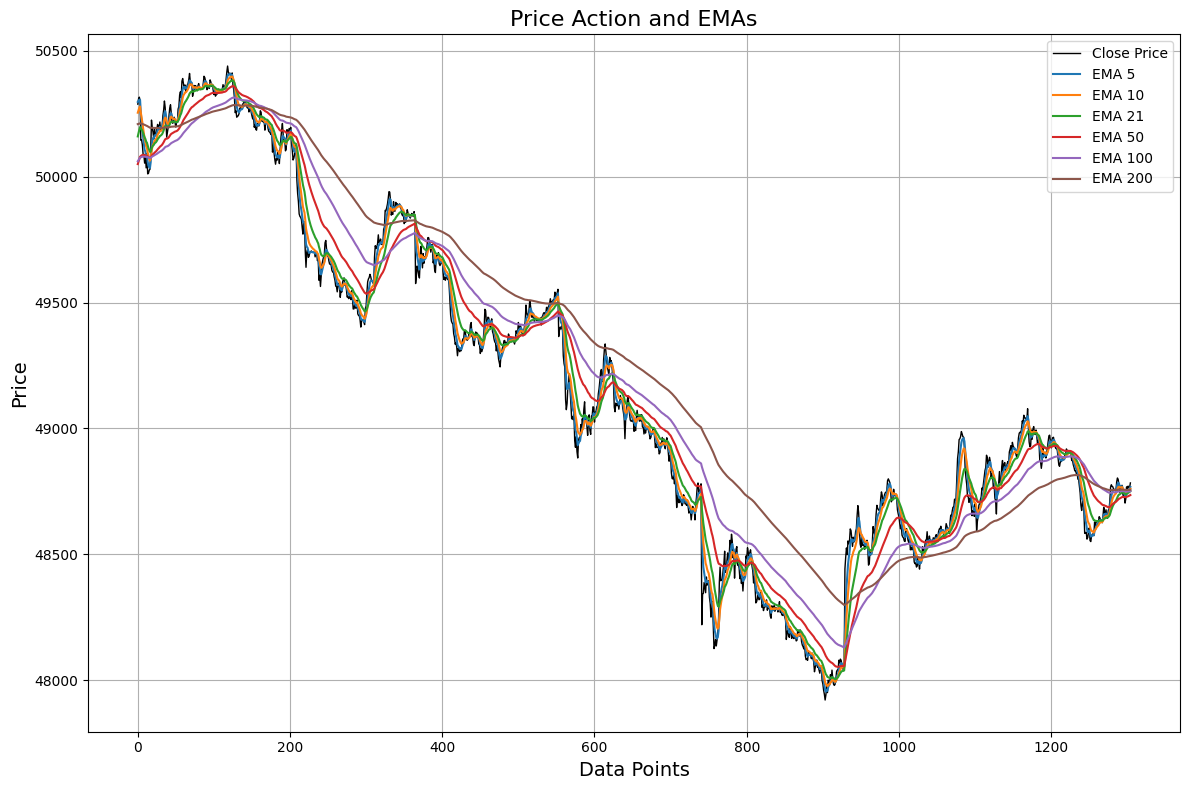

In [15]:
def visualize_ema(df):
    plt.figure(figsize=(12, 8))

    # Plot the Close price using the length of the DataFrame for the x-axis
    plt.plot(range(len(df)), df['close'], label='Close Price', color='black', linewidth=1)

    # Plot EMAs using the length of the DataFrame for the x-axis
    ema_periods = [5, 10, 21, 50, 100, 200]
    for period in ema_periods:
        plt.plot(range(len(df)), df[f'ema_{period}'], label=f'EMA {period}')

    # Customize the plot
    plt.title("Price Action and EMAs", fontsize=16)
    plt.xlabel('Data Points', fontsize=14)
    plt.ylabel('Price', fontsize=14)
    plt.legend()
    plt.grid(True)

    # Show the plot
    plt.tight_layout()
    plt.show()


visualize_ema(processed_df)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = processed_df.drop(columns=['Signal'])
y = processed_df['Signal']

model = RandomForestClassifier()
model.fit(X, y)

# Feature importance
importance = model.feature_importances_
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importance})
feature_importance.sort_values(by='Importance', ascending=False, inplace=True)

feature_importance

,Feature,Importance
6,oc_change,0.102618
5,cl_position,0.086868
1,high,0.082120
2,low,0.082110
3,close,0.081385
8,std_dev,0.081340
0,open,0.080710
4,hl_range,0.069126
7,atr,0.068599
9,Dynamic ATR,0.067023


In [ ]:
processed_df.columns

Index(['open', 'high', 'low', 'close', 'hl_range', 'cl_position', 'oc_change',
       'atr', 'std_dev', 'Dynamic ATR', 'Target', 'Stop Loss', 'Buy Entry',
       'Sell Entry', 'Signal'],
      dtype='object')

In [ ]:
# Assuming `processed_df` is sorted by time
split_ratio = 0.8  # 80% training, 20% evaluation

# Calculate the split index
split_index = int(len(processed_df) * split_ratio)

# Create training and evaluation datasets
train_processed_df = processed_df.iloc[:split_index]
eval_processed_df = processed_df.iloc[split_index:]

print(len(train_processed_df), len(eval_processed_df))

10240 2561


In [ ]:
def scale_data(df):
    original_df = df.copy()

    # Apply MinMaxScaler to the columns (excluding 'Signal' if present)
    scaler = MinMaxScaler()
    columns_to_scale = [col for col in df.columns if col != 'Signal']
    scaled_data = scaler.fit_transform(df[columns_to_scale].copy())

    # Convert scaled data back to a dataframe
    scaled_df = pd.DataFrame(scaled_data, columns=columns_to_scale, index=df.index)

    # Add 'Signal' column back if it was excluded
    if 'Signal' in df.columns:
        scaled_df['Signal'] = df['Signal']

    return scaled_df, original_df, scaler

Version 1

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import os

class LSTMClassificationPipeline:
    def __init__(self, sequence_length=60, batch_size=32, epochs=100, model_path='lstm_model.keras'):
        self.sequence_length = sequence_length
        self.batch_size = batch_size
        self.epochs = epochs
        self.model_path = model_path
        self.model = None
        self.scaler = None
        self.feature_columns = None

    def scale_data(self, df, is_training=True):
        """Scale the input data"""
        if is_training:
            # Store feature columns for prediction
            self.feature_columns = [col for col in df.columns if col != 'Signal']

            # Fit scaler on training data
            self.scaler = MinMaxScaler()
            scaled_data = self.scaler.fit_transform(df[self.feature_columns])
        else:
            if self.scaler is None:
                raise ValueError("Scaler not fitted. Train the model first.")
            if not all(col in df.columns for col in self.feature_columns):
                raise ValueError(f"Prediction data must contain all training features: {self.feature_columns}")

            # Transform prediction data using fitted scaler
            scaled_data = self.scaler.transform(df[self.feature_columns])

        # Convert scaled data back to dataframe
        scaled_df = pd.DataFrame(scaled_data, columns=self.feature_columns, index=df.index)

        # Add Signal column if present (training data)
        if 'Signal' in df.columns and is_training:
            scaled_df['Signal'] = df['Signal']

        return scaled_df

    def prepare_sequences(self, df, is_training=True):
        """Prepare sequences for LSTM input"""
        sequences = []
        targets = []

        # Use all features except Signal for sequences
        feature_data = df[self.feature_columns] if is_training else df

        for i in range(len(df) - self.sequence_length):
            seq = feature_data.iloc[i:(i + self.sequence_length)].values
            sequences.append(seq)

            if is_training:
                target = df['Signal'].iloc[i + self.sequence_length]
                targets.append(target)

        if is_training:
            return np.array(sequences), np.array(targets)
        return np.array(sequences)

    def create_model(self, input_shape, num_classes=3):
        """Create LSTM model architecture"""
        model = Sequential([
            Input(shape=input_shape),  # Use Input layer explicitly
            LSTM(128, return_sequences=True),
            BatchNormalization(),
            Dropout(0.3),

            LSTM(64, return_sequences=True),
            BatchNormalization(),
            Dropout(0.3),

            LSTM(32),
            BatchNormalization(),
            Dropout(0.3),

            Dense(16, activation='relu'),
            BatchNormalization(),
            Dropout(0.2),

            Dense(num_classes, activation='softmax')
        ])

        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        return model

    def setup_callbacks(self):
        """Set up training callbacks"""
        return [
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-6,
                verbose=1
            ),
            EarlyStopping(
                monitor='val_loss',
                patience=15,
                restore_best_weights=True,
                verbose=1
            ),
            ModelCheckpoint(
                self.model_path,
                monitor='val_loss',
                save_best_only=True,
                verbose=1
            )
        ]

    def train(self, df):
        """Train the model"""
        # Scale training data
        scaled_df = self.scale_data(df, is_training=True)

        # Prepare sequences
        X, y = self.prepare_sequences(scaled_df, is_training=True)

        # Split data
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

        # Load existing model or create new one
        if os.path.exists(self.model_path):
            print("Loading existing model...")
            self.model = load_model(self.model_path)
        else:
            print("Creating new model...")
            self.model = self.create_model(input_shape=(X.shape[1], X.shape[2]))

        # Train model
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            batch_size=self.batch_size,
            epochs=self.epochs,
            callbacks=self.setup_callbacks(),
            verbose=1
        )

        return history

    def predict(self, df, return_probabilities=False):
        """Make predictions on new data"""
        if self.model is None:
            raise ValueError("Model not trained. Please train the model first.")

        # Scale prediction data
        scaled_df = self.scale_data(df, is_training=False)

        # Prepare sequences
        X = self.prepare_sequences(scaled_df, is_training=False)

        # Make predictions
        probabilities = self.model.predict(X)
        if return_probabilities:
            return probabilities
        return np.argmax(probabilities, axis=1)

In [ ]:
# Initialize pipeline
pipeline = LSTMClassificationPipeline(
    sequence_length=60,
    batch_size=32,
    epochs=100,
    model_path='lstm_model.keras'
)

# Train the model (with Signal column)
history = pipeline.train(processed_df)

Creating new model...
Epoch 1/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.4559 - loss: 1.1864
Epoch 1: val_loss improved from inf to 0.82069, saving model to lstm_model.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 48s 112ms/step - accuracy: 0.4562 - loss: 1.1859 - val_accuracy: 0.7109 - val_loss: 0.8207 - learning_rate: 0.0010
Epoch 2/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.6803 - loss: 0.8597
Epoch 2: val_loss improved from 0.82069 to 0.80460, saving model to lstm_model.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 41s 130ms/step - accuracy: 0.6804 - loss: 0.8596 - val_accuracy: 0.7109 - val_loss: 0.8046 - learning_rate: 0.0010
Epoch 3/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.7065 - loss: 0.8297
Epoch 3: val_loss did not improve from 0.80460
319/319 ━━━━━━━━━━━━━━━━━━━━ 41s 128ms/step - accuracy: 0.7065 - loss: 0.8297 - val_accuracy: 0.7109 - val_loss: 0.8486 - learning_rate: 0.0010
Epoch 4/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 

In [ ]:
# Make predictions (without Signal column)
# Assuming new_data is your DataFrame without the Signal column
predictions = pipeline.predict(processed_df)

# Get prediction probabilities
#probabilities = pipeline.predict(processed_df, return_probabilities=True)

399/399 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step


array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

Version 2

In [ ]:
class TradingEnvironment(gym.Env):
    def __init__(self, data, config):
        super(TradingEnvironment, self).__init__()

        scaled_df, original_df, scaler = scale_data(data)

        self.data = scaled_df.to_numpy()
        self.original_data = original_df.to_numpy()

        self.columns = scaled_df.columns.tolist()

        # Remove the 'Signal' column for observations
        if 'Signal' in self.columns:
            self.signal_idx = self.columns.index('Signal')
            self.columns.remove('Signal')  # Exclude 'Signal' from columns
        else:
            self.signal_idx = None

        self.config = config
        self.window_size = config['window_size']
        self.current_step = 0
        self.done = False
        self.balance = float(config['initial_capital'])
        self.quantity = config['quantity']
        self.position = 0
        self.entry_price = 0.0
        self.target_price = 0.0
        self.stop_loss_price = 0.0
        self.brokerage = config['brokerage']
        self.trades_log = []
        self.holding_duration = 0
        self.rewards = []
        self.profit_streak = 0
        self.loss_streak = 0

        # Action Space: 0 = Hold, 1 = Buy, 2 = Sell
        self.action_space = spaces.Discrete(3)

        # Observation Space: Flattened data window
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.window_size, len(self.columns)), dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.done = False
        self.balance = float(self.config['initial_capital'])
        self.position = 0
        self.entry_price = 0.0
        self.target_price = 0.0
        self.stop_loss_price = 0.0
        self.trades_log = []
        self.holding_duration = 0
        self.rewards = []
        self.profit_streak = 0
        self.loss_streak = 0
        return self._get_state(), {}

    def _get_state(self):
        state = self.data[self.current_step - self.window_size:self.current_step]
        if self.signal_idx is not None:
            state = np.delete(state, self.signal_idx, axis=1)  # Remove 'Signal' column dynamically
        return state

    def step(self, action):
        price = self.original_data[self.current_step, self.columns.index('close')]
        target_points = self.original_data[self.current_step, self.columns.index('Target')]
        stop_loss_points = self.original_data[self.current_step, self.columns.index('Stop Loss')]
        signal = self.original_data[self.current_step, self.signal_idx] if self.signal_idx is not None else None

        reward = 0
        profit_loss = 0.0

        # Handle open positions
        if self.position != 0:
            self.holding_duration += 1
            if (self.position == 1 and price >= self.target_price) or (self.position == -1 and price <= self.target_price):
                captured_points = abs(self.target_price - self.entry_price)
                profit_loss = captured_points * self.quantity
                self.balance += profit_loss  # Add profit to balance
                reward += 100  # Reward for hitting the target
                self.profit_streak += 1
                self.loss_streak = 0
                self._log_trade(price, "Target Hit")
                self.position = 0
                self.holding_duration = 0

            elif (self.position == 1 and price <= self.stop_loss_price) or (self.position == -1 and price >= self.stop_loss_price):
                captured_points = abs(self.entry_price - self.stop_loss_price)
                profit_loss = -captured_points * self.quantity
                self.balance += profit_loss  # Subtract loss from balance
                reward -= 100  # Penalty for hitting stop loss
                self.loss_streak += 1
                self.profit_streak = 0
                self._log_trade(price, "Stop Loss Hit")
                self.position = 0
                self.holding_duration = 0

            # Reward for profit streaks
            if self.profit_streak > 0:
                reward += 20 * self.profit_streak  # Amplify reward for profit streaks
            elif self.loss_streak > 0:
                reward -= 20 * self.loss_streak  # Amplify penalty for loss streaks

        # Handle new actions
        if self.position == 0:
            if action == 1:  # Buy
                self.position = 1
                self.entry_price = price
                self.target_price = price + target_points
                self.stop_loss_price = price - stop_loss_points

                if signal == 1:
                    reward += 200
                elif signal == 2:
                    reward -= 200

            elif action == 2:  # Sell
                self.position = -1
                self.entry_price = price
                self.target_price = price - target_points
                self.stop_loss_price = price + stop_loss_points

                if signal == 2:
                    reward += 200
                elif signal == 1:
                    reward -= 200

            elif action == 0: # Hold
                if signal == 1 or signal == 2:
                    reward -= 25

        # Penalize overtrading or revenge trading
        if len(self.trades_log) > 1:
            last_trade = self.trades_log[-1]
            if last_trade['Status'] in ["Stop Loss Hit", "Target Hit"]:
                time_since_last_trade = self.current_step - last_trade['Exit Step']
                if time_since_last_trade < self.config['min_trade_gap']:
                    reward -= 20  # Penalty for revenge trading

        # Update simulation
        self.current_step += 1
        if self.current_step >= len(self.data) or self.balance <= 0:
            self.done = True

        self.rewards.append(reward)
        info = {
            'Entry Price': self.entry_price,
            'Current Price': price,
            'Target Price': f"{self.target_price} ({target_points})",
            'Stop Loss Price': f"{self.stop_loss_price} ({stop_loss_points})",
            'Holding Duration': self.holding_duration,
            'Position': self.position,
            'Profit Streak': self.profit_streak,
            'Loss Streak': self.loss_streak,
            'Balance': self.balance,
            'Profit/Loss': profit_loss,
            'Reward': reward,
        }
        return self._get_state(), reward, self.done, False, info

    def _log_trade(self, price, status):
        entry_type = "Buy" if self.position == 1 else "Sell" if self.position == -1 else "hold"
        self.trades_log.append({
            'Entry Type': entry_type,
            'Entry Price': self.entry_price,
            'Exit Price': price,
            'Target Price': self.target_price,
            'Stop Loss Price': self.stop_loss_price,
            'Holding Duration': self.holding_duration,
            'Status': status,
            'Signal': self.data[self.current_step, self.signal_idx] if self.signal_idx is not None else None,
            'Exit Step': self.current_step
        })

    def get_trade_logs(self):
        return pd.DataFrame(self.trades_log)

    def calculate_metrics(self):
        win_rate = 0.0

        if (len(self.trades_log) > 0):
            pnl = [t['Exit Price'] - t['Entry Price'] if t['Status'] == "Target Hit" else t['Entry Price'] - t['Exit Price'] for t in self.trades_log]
            pnl = np.array(pnl)

            # Win Rate
            wins = sum([1 for t in self.trades_log if t['Status'] == "Target Hit"])
            total_trades = len(self.trades_log)
            win_rate = (wins / total_trades) * 100 if total_trades > 0 else 0

        return {
            "Win Rate": win_rate
        }

    def print_trade_summary(self):
        metrics = self.calculate_metrics()
        print(f"\nFinal Balance: {self.balance:.2f}")
        print(f"Total Trades: {len(self.trades_log)}")
        print(f"Profitable Trades: {sum([1 for t in self.trades_log if t['Status'] == 'Target Hit'])}")
        print(f"Win Rate: {metrics['Win Rate']:.2f}%")

    def render(self, mode='human'):
        metrics = self.calculate_metrics()
        win_rate = metrics["Win Rate"]

        # Map position to the desired format
        position_display = "0 (Hold)" if self.position == 0 else "1 (Buy)" if self.position == 1 else "-1 (Sell)"

        # Log the information
        print(f"Step: {self.current_step}, Balance: {self.balance:.2f}, Position: {position_display}, Win Rate: {win_rate:.2f}%")

    def close(self):
        pass

In [ ]:
# Configuration
config = {
    'window_size': 15,
    'initial_capital': 10000,
    'quantity': quantity,
    'min_trade_gap': 5,
    'brokerage': 20,
    'learning_rate': 0.001,
    'gamma': 0.99
}

# Check for GPU availability and set memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        device = 'cuda'  # Use GPU
    except RuntimeError as e:
        print(e)
        device = 'cpu'
else:
    device = 'cpu'  # Fall back to CPU
print(f"Training will use {'GPU' if gpus else 'CPU'}.")

In [ ]:
import os
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback

# Define paths for saving models
model_save_path = "ppo_trading_model"
tensorboard_log_dir = "./ppo_tensorboard"

# Ensure Tensorboard log directory exists
os.makedirs(tensorboard_log_dir, exist_ok=True)

def create_env(processed_df, config):
    """Create and return the trading environment."""
    return DummyVecEnv([lambda: TradingEnvironment(processed_df, config)])

def dynamic_learning_rate(progress: float):
    """Dynamic learning rate: starts at 3e-4 and decays linearly."""
    return 3e-4 * (1 - progress)

def dynamic_clip_range(progress: float):
    """Dynamic clip range: starts at 0.2 and decays linearly."""
    return 0.2 * (1 - progress)

def dynamic_entropy_coefficient(progress: float):
    """Dynamic entropy coefficient: decreases as training progresses."""
    return 0.01 * (1 - progress)

def dynamic_value_function_coefficient(progress: float):
    """Dynamic value function coefficient: increases as training progresses."""
    return 0.5 + (0.5 * progress)

class DynamicParametersCallback(BaseCallback):
    def __init__(self, total_timesteps, verbose=0):
        super(DynamicParametersCallback, self).__init__(verbose)
        self.total_timesteps = total_timesteps

    def _on_step(self) -> bool:
        # Calculate training progress
        progress = self.num_timesteps / self.total_timesteps

        # Dynamically adjust parameters by assigning callable lambdas
        self.model.lr_schedule = lambda _: dynamic_learning_rate(progress)
        self.model.clip_range = lambda _: dynamic_clip_range(progress)
        self.model.ent_coef = dynamic_entropy_coefficient(progress)
        self.model.vf_coef = dynamic_value_function_coefficient(progress)

        return True

def initialize_model(env, learning_rate, clip_range, ent_coef, vf_coef):
    """Initialize a PPO model with dynamic parameters."""
    return PPO(
        "MlpPolicy",          # Use MLP policy for numerical data
        env,                  # Environment to train the model
        verbose=1,            # Verbosity level for logging
        tensorboard_log=tensorboard_log_dir,  # Path for Tensorboard logs
        n_steps=2048,         # Number of steps per update
        batch_size=32,       # Dynamic batch size (calculated before)
        gamma=0.99,           # Discount factor (kept static for now)
        learning_rate=learning_rate,  # Dynamic learning rate
        clip_range=clip_range,        # Dynamic clip range
        ent_coef=ent_coef,          # Dynamic entropy coefficient
        vf_coef=vf_coef,          # Dynamic value function coefficient
        max_grad_norm=0.5,    # Maximum gradient norm (static)
    )

def load_or_train_model(env, total_timesteps):
    """Load an existing PPO model or train a new one."""
    if os.path.exists(model_save_path + ".zip"):
        print("Loading existing model...")
        model = PPO.load(model_save_path, env=env, device="cuda")
        print("Continuing training...")
    else:
        print("No existing model found. Training a new model...")

        # Initialize with default parameters
        progress = 0
        learning_rate = dynamic_learning_rate(progress)
        clip_range = dynamic_clip_range(progress)
        ent_coef = dynamic_entropy_coefficient(progress)
        vf_coef = dynamic_value_function_coefficient(progress)

        model = initialize_model(env, learning_rate, clip_range, ent_coef, vf_coef)

    # Add the dynamic parameters callback
    dynamic_params_callback = DynamicParametersCallback(total_timesteps)

    model.learn(total_timesteps=total_timesteps, callback=dynamic_params_callback)
    model.save(model_save_path)
    print(f"Model saved to {model_save_path}")
    return model

ppo_train_env = create_env(train_processed_df, config)

# Define the total timesteps for training
TOTAL_TIMESTEPS = 50000

# Load or train the model
ppo_model = load_or_train_model(ppo_train_env, TOTAL_TIMESTEPS)

In [ ]:
# Evaluation
print("Evaluating the PPO model...")
ppo_test_env = TradingEnvironment(eval_processed_df, config)
obs, _ = ppo_test_env.reset()
done = False
total_rewards = 0
while not done:
    action, _ = ppo_model.predict(obs, deterministic=True)
    obs, reward, done, _, info = ppo_test_env.step(action)
    total_rewards += reward
    ppo_test_env.render()

print(f"Total Rewards during Evaluation: {total_rewards}")

In [ ]:
ppo_test_env.print_trade_summary()

In [ ]:
ppo_test_env.get_trade_logs()

In [ ]:
# Variables to track streaks
max_profit_streak = 0
max_loss_streak = 0
current_profit_streak = 0
current_loss_streak = 0

# Check if 'Status' column exists
trade_logs = ppo_test_env.get_trade_logs()
if "Status" in trade_logs.columns:
    # Check if both 'Target Hit' and 'Stop Loss Hit' exist in the Status column
    if trade_logs["Status"].str.contains("Target Hit").any() and trade_logs["Status"].str.contains("Stop Loss Hit").any():
        # Iterate through the 'Status' column
        for status in trade_logs["Status"]:
            if status == "Target Hit":
                current_profit_streak += 1
                current_loss_streak = 0
            elif status == "Stop Loss Hit":
                current_loss_streak += 1
                current_profit_streak = 0
            else:
                current_profit_streak = 0
                current_loss_streak = 0

            # Update max streaks
            max_profit_streak = max(max_profit_streak, current_profit_streak)
            max_loss_streak = max(max_loss_streak, current_loss_streak)

        # Print the results
        print(f"Highest Profit Streak (Target Hit): {max_profit_streak}")
        print(f"Highest Loss Streak (Stop Loss Hit): {max_loss_streak}")
    else:
        print("The 'Status' column does not contain 'Target Hit' or 'Stop Loss Hit' values.")
else:
    print("The 'Status' column does not exist in the trade logs.")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output
import time

def visualize_trades_matplotlib(env, data):
    trades = env.get_trade_logs()
    close_prices = data['close'].values

    # Initialize the figure and axis
    fig, ax = plt.subplots(figsize=(14, 7))

    # Plot for the price line
    line, = ax.plot([], [], label='Close Price', color='blue')

    # Entry and exit markers
    entry_marker, = ax.plot([], [], 'o', color='orange', markersize=8, label='Entry')
    target_marker, = ax.plot([], [], '^', color='green', markersize=10, label='Target Hit')
    stop_loss_marker, = ax.plot([], [], 'v', color='red', markersize=10, label='Stop Loss Hit')

    # Set axis labels
    ax.set_title('Trade Visualization on Closing Price Chart')
    ax.set_xlabel('Steps')
    ax.set_ylabel('Price')

    # Add a legend
    ax.legend()

    # Set initial limits for the axes
    ax.set_xlim(0, 100)
    ax.set_ylim(np.min(close_prices) * 0.95, np.max(close_prices) * 1.05)

    # Update the plot dynamically
    for step in range(100, len(close_prices) + 1):
        # Update price line
        line.set_xdata(np.arange(step))
        line.set_ydata(close_prices[:step])

        # Add trade details dynamically
        entry_x, entry_y = [], []
        target_x, target_y = [], []
        stop_loss_x, stop_loss_y = [], []
        path_x, path_y = [], []
        path_colors = []  # List to store colors for each trade path

        for _, trade in trades.iterrows():
            entry_step = trade['Exit Step'] - trade['Holding Duration']
            exit_step = trade['Exit Step']

            if exit_step > step:
                continue

            # Collect entry points
            if entry_step <= step:
                entry_x.append(entry_step)
                entry_y.append(close_prices[entry_step])

            # Collect exit points
            if exit_step <= step:
                if trade['Status'] == 'Target Hit':
                    target_x.append(exit_step)
                    target_y.append(close_prices[exit_step])
                elif trade['Status'] == 'Stop Loss Hit':
                    stop_loss_x.append(exit_step)
                    stop_loss_y.append(close_prices[exit_step])

                # Add path points
                path_x.extend([entry_step, exit_step, None])
                path_y.extend([close_prices[entry_step], close_prices[exit_step], None])

                # Determine the path color based on the trade outcome
                if trade['Status'] == 'Target Hit':  # Profit
                    path_colors.extend(['green', 'green', 'none'])
                elif trade['Status'] == 'Stop Loss Hit':  # Loss
                    path_colors.extend(['red', 'red', 'none'])

        # Update entry, target, stop loss markers
        entry_marker.set_xdata(entry_x)
        entry_marker.set_ydata(entry_y)

        target_marker.set_xdata(target_x)
        target_marker.set_ydata(target_y)

        stop_loss_marker.set_xdata(stop_loss_x)
        stop_loss_marker.set_ydata(stop_loss_y)

        # Update trade paths with dynamic colors
        for i in range(0, len(path_x), 3):
            ax.plot(path_x[i:i+2], path_y[i:i+2], color=path_colors[i], linestyle='--')

        # Adjust the visible range dynamically
        visible_close_prices = close_prices[max(0, step - 100):step]

        # Update y-axis range based on the current visible close prices
        y_min = np.min(visible_close_prices) * 1  # Tightened buffer around min price
        y_max = np.max(visible_close_prices) * 1  # Tightened buffer around max price

        # Update y-axis range dynamically, ensuring tighter scaling
        ax.set_ylim(y_min, y_max)

        # Update x-axis range to be consistent with visible steps
        ax.set_xlim(max(0, step - 100), step)

        # Display the updated chart
        clear_output(wait=True)
        display(fig)
        time.sleep(0.001)

# Example usage
#visualize_trades_matplotlib(ppo_test_env, train_processed_df)

Version 3

In [ ]:
import tensorflow as tf

# Enable GPU memory growth to prevent OOM errors
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    for device in physical_devices:
        tf.config.experimental.set_memory_growth(device, True)
    print("GPU is available and configured")
else:
    print("No GPU devices found, using CPU")

# Set mixed precision policy for better GPU performance
tf.keras.mixed_precision.set_global_policy('mixed_float16')

In [ ]:

import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
from collections import deque
import pickle
import os

def compute_std(x, axis=None, keepdims=False):
    mean = tf.reduce_mean(x, axis=axis, keepdims=True)
    squared_deviations = tf.square(x - mean)
    variance = tf.reduce_mean(squared_deviations, axis=axis, keepdims=keepdims)
    return tf.sqrt(variance + 1e-8)

class EpisodicMemory:
    def __init__(self, max_size=10000):
        self.memory = deque(maxlen=max_size)
        self.memory_file = "episodic_memory.pkl"
        self.market_patterns = deque(maxlen=1000)

    def add_episode(self, states, actions, rewards, meta_features, final_reward):
        episode_data = {
            'states': states,
            'actions': actions,
            'rewards': rewards,
            'meta_features': meta_features,
            'final_reward': final_reward
        }
        self.memory.append(episode_data)

        if final_reward > 0:
            self.market_patterns.append({
                'states': states,
                'meta_features': meta_features,
                'reward': final_reward
            })

    def sample_episodes(self, n_episodes):
        if len(self.memory) < n_episodes:
            return list(self.memory)
        episodes = list(self.memory)
        episodes.sort(key=lambda x: x['final_reward'], reverse=True)
        return episodes[:n_episodes]

    def get_successful_patterns(self, n_patterns=5):
        if len(self.market_patterns) < n_patterns:
            return list(self.market_patterns)
        return list(sorted(self.market_patterns, key=lambda x: x['reward'], reverse=True))[:n_patterns]

    def save_memory(self):
        with open(self.memory_file, 'wb') as f:
            pickle.dump({
                'episodes': list(self.memory),
                'patterns': list(self.market_patterns)
            }, f)

    def load_memory(self):
        if os.path.exists(self.memory_file):
            with open(self.memory_file, 'rb') as f:
                data = pickle.load(f)
                self.memory.extend(data['episodes'])
                self.market_patterns.extend(data['patterns'])

class MetaFeatureExtractor(Model):
    def __init__(self, input_shape):
        super(MetaFeatureExtractor, self).__init__()

        # CNN layers for feature extraction
        self.cnn_stack = tf.keras.Sequential([
            layers.Conv1D(64, 3, activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling1D(2),
            layers.Conv1D(128, 3, activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling1D(2),
            layers.Conv1D(64, 3, activation='relu', padding='same'),
            layers.BatchNormalization()
        ])

        # LSTM layers for temporal dependencies
        self.lstm_stack = tf.keras.Sequential([
            layers.LSTM(128, return_sequences=True),
            layers.LSTM(64)
        ])

        # Final dense layers
        self.dense_stack = tf.keras.Sequential([
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.2),
            layers.Dense(32, activation='relu')
        ])

    @tf.function
    def call(self, x, training=False):
        x = tf.cast(x, tf.float32)
        # CNN feature extraction
        x = self.cnn_stack(x, training=training)
        # LSTM processing
        x = self.lstm_stack(x)
        # Dense processing
        x = self.dense_stack(x, training=training)
        return x

class AdaptivePolicy(Model):
    def __init__(self, state_dim, action_dim):
        super(AdaptivePolicy, self).__init__()

        # LSTM for sequential processing
        self.lstm_stack = tf.keras.Sequential([
            layers.LSTM(128, return_sequences=True, return_state=True),
            layers.LSTM(64, return_state=True)
        ])

        # Attention mechanism
        self.attention = layers.MultiHeadAttention(num_heads=4, key_dim=32)

        # Policy network
        self.policy_network = tf.keras.Sequential([
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.2),
            layers.Dense(32, activation='relu'),
            layers.Dense(action_dim)
        ])

        # Value network
        self.value_network = tf.keras.Sequential([
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.2),
            layers.Dense(32, activation='relu'),
            layers.Dense(1)
        ])

    @tf.function
    def call(self, inputs, training=False):
        state, meta_features = inputs

        # Process state through LSTM
        lstm_out, state_h, state_c = self.lstm_stack(state)

        # Combine LSTM output with meta features
        combined = tf.concat([lstm_out, meta_features], axis=-1)

        # Apply attention
        attn_out = self.attention(
            tf.expand_dims(combined, axis=1),
            tf.expand_dims(combined, axis=1),
            tf.expand_dims(combined, axis=1)
        )
        attn_out = tf.squeeze(attn_out, axis=1)

        # Get policy and value outputs
        policy_logits = self.policy_network(attn_out, training=training)
        policy = tf.nn.softmax(policy_logits, axis=-1)
        value = self.value_network(attn_out, training=training)

        return policy, value

class MetaTrader:
    def __init__(self, env, config):
        self.env = env
        self.config = config
        self.state_dim = env.observation_space.shape
        self.action_dim = env.action_space.n

        # Initialize networks
        self.meta_feature_extractor = MetaFeatureExtractor(self.state_dim)
        self.policy = AdaptivePolicy(self.state_dim, self.action_dim)

        # Initialize memory
        self.episodic_memory = EpisodicMemory()
        self.episodic_memory.load_memory()

        # Initialize optimizers with learning rate schedules
        self.meta_lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            config['meta_lr'], decay_steps=1000, decay_rate=0.95)
        self.policy_lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            config['policy_lr'], decay_steps=1000, decay_rate=0.95)

        self.meta_optimizer = tf.keras.optimizers.Adam(learning_rate=self.meta_lr_schedule)
        self.policy_optimizer = tf.keras.optimizers.Adam(learning_rate=self.policy_lr_schedule)

        # Training metrics
        self.train_episode_reward = tf.keras.metrics.Mean('train_episode_reward')
        self.win_rate = tf.keras.metrics.Mean('win_rate')

        # Episode counter for epsilon decay
        self.episode_count = 0

        # Enable XLA compilation for faster GPU execution
        tf.config.optimizer.set_jit(True)

        # Use mixed precision optimizers
        self.meta_optimizer = tf.keras.optimizers.Adam(
            learning_rate=self.meta_lr_schedule,
            epsilon=1e-4  # Increased epsilon for mixed precision training
        )
        self.policy_optimizer = tf.keras.optimizers.Adam(
            learning_rate=self.policy_lr_schedule,
            epsilon=1e-4
        )

        # Initialize strategy for multi-GPU if available
        if len(physical_devices) > 1:
            self.strategy = tf.distribute.MirroredStrategy()
        else:
            self.strategy = tf.distribute.get_strategy()



    @tf.function  # Add tf.function for GPU acceleration
    def get_action(self, state, meta_features, training=False):
        policy, _ = self.policy([state, meta_features], training=training)

        if training:
            # Use GPU for random sampling
            epsilon = tf.constant(max(0.01, 0.1 * (0.995 ** self.episode_count)), dtype=tf.float32)
            random_sample = tf.random.uniform(shape=(), dtype=tf.float32)

            if random_sample < epsilon:
                action = tf.random.uniform(shape=(), maxval=self.action_dim, dtype=tf.int32)
            else:
                action = tf.cast(tf.argmax(policy[0], axis=-1), dtype=tf.int32)  # Ensure int32
        else:
            action = tf.cast(tf.argmax(policy[0], axis=-1), dtype=tf.int32)  # Ensure int32

        return action


    def extract_meta_features(self, states, training=False):
        return self.meta_feature_extractor(states, training=training)

    def _compute_advantages(self, rewards, values):
        rewards = tf.cast(rewards, dtype=tf.float32)
        values = tf.cast(values, dtype=tf.float32)

        advantages = rewards - tf.squeeze(values)
        mean = tf.reduce_mean(advantages)
        std = compute_std(advantages)
        return (advantages - mean) / (std + 1e-8)

    @tf.function  # Add tf.function for GPU acceleration
    def update_networks(self, states, actions, rewards, meta_features, importance_weights=None):
        if importance_weights is None:
            importance_weights = tf.ones_like(rewards)
            importance_weights = tf.cast(importance_weights, dtype=tf.float32)

        with tf.GradientTape() as tape:
            policy, values = self.policy([states, meta_features], training=True)
            advantages = self._compute_advantages(rewards, values)

            # Ensure all tensors have the same dtype
            rewards = tf.cast(rewards, dtype=tf.float32)
            policy = tf.cast(policy, dtype=tf.float32)
            values = tf.cast(values, dtype=tf.float32)
            advantages = tf.cast(advantages, dtype=tf.float32)

            # Policy loss with proper shapes
            actions_onehot = tf.one_hot(actions, self.action_dim, dtype=tf.float32)
            log_probs = tf.math.log(tf.clip_by_value(policy, 1e-10, 1.0))
            log_probs = tf.cast(log_probs, dtype=tf.float32)
            policy_loss = -tf.reduce_mean(
                tf.reduce_sum(actions_onehot * log_probs, axis=-1) * advantages * importance_weights
            )

            # Value loss
            value_loss = tf.reduce_mean(tf.square(rewards - tf.squeeze(values)) * importance_weights)

            # Entropy regularization
            entropy = -tf.reduce_mean(tf.reduce_sum(policy * log_probs, axis=-1))

            # Scale loss for mixed precision
            total_loss = tf.cast(
                policy_loss + 0.5 * value_loss - 0.01 * entropy,
                dtype=tf.float32
            )

        # Update networks with GPU optimization
        grads = tape.gradient(total_loss, self.policy.trainable_variables)
        grads = [tf.clip_by_norm(g, 1.0) for g in grads]
        self.policy_optimizer.apply_gradients(zip(grads, self.policy.trainable_variables))

        return total_loss, policy_loss, value_loss, entropy

    def train_episode(self):
        # Convert numpy arrays to tensors and move to GPU
        state = self.env.reset()[0]
        state = tf.convert_to_tensor(state, dtype=tf.float32)

        done = False
        episode_states = []
        episode_actions = []
        episode_rewards = []
        episode_reward = 0

        while not done:
            # Move data to GPU
            state_gpu = tf.expand_dims(state, 0)
            meta_features = self.extract_meta_features(state_gpu, training=True)

            # Get action using GPU
            action = self.get_action(state_gpu, meta_features, training=True)
            action = int(action.numpy())  # Convert back to CPU for environment

            # Take action in environment
            next_state, reward, done, _, info = self.env.step(action)

            # Store transition
            episode_states.append(state.numpy())
            episode_actions.append(action)
            episode_rewards.append(reward)
            episode_reward += reward

            state = tf.convert_to_tensor(next_state, dtype=tf.float32)

        # Batch process on GPU
        states = tf.convert_to_tensor(episode_states, dtype=tf.float32)
        actions = tf.convert_to_tensor(episode_actions, dtype=tf.int32)
        rewards = tf.convert_to_tensor(episode_rewards, dtype=tf.float32)
        meta_features = self.extract_meta_features(states, training=True)

        meta_features = tf.cast(meta_features, dtype=tf.float32)

        # Compute importance weights on GPU
        rewards_std = compute_std(rewards)
        importance_weights = tf.exp(rewards / (rewards_std + 1e-8))

        importance_weights = tf.cast(importance_weights, dtype=tf.float32)

        # Update networks using GPU
        losses = self.update_networks(states, actions, rewards, meta_features, importance_weights)

        # Store episode and update metrics
        self.episodic_memory.add_episode(
            states.numpy(),
            actions.numpy(),
            rewards.numpy(),
            meta_features.numpy(),
            episode_reward
        )

        self._learn_from_patterns()
        self.train_episode_reward(episode_reward)
        self.episode_count += 1

        return episode_reward, losses

    def _learn_from_patterns(self):
        # Get successful patterns
        patterns = self.episodic_memory.get_successful_patterns()
        if not patterns:
            return

        # Learn from each pattern
        for pattern in patterns:
            states = tf.convert_to_tensor(pattern['states'], dtype=tf.float32)
            meta_features = tf.convert_to_tensor(pattern['meta_features'], dtype=tf.float32)

            with tf.GradientTape() as tape:
                extracted_features = self.meta_feature_extractor(states, training=True)
                feature_loss = tf.reduce_mean(tf.square(extracted_features - meta_features))

            grads = tape.gradient(feature_loss, self.meta_feature_extractor.trainable_variables)
            self.meta_optimizer.apply_gradients(
                zip(grads, self.meta_feature_extractor.trainable_variables))

    def train(self, num_episodes):
        best_reward = float('-inf')
        no_improvement_count = 0

        for episode in range(num_episodes):
            episode_reward, (total_loss, policy_loss, value_loss, entropy) = self.train_episode()

            # Early stopping with patience
            if episode_reward > best_reward:
                best_reward = episode_reward
                no_improvement_count = 0
                # Save best model
                self.save_models("saved_models/meta_trader_best")
            else:
                no_improvement_count += 1

            if no_improvement_count >= 100:  # Patience of 100 episodes
                print("Early stopping triggered!")
                break

            if episode % 10 == 0:
                print(f"Episode {episode}")
                print(f"Reward: {episode_reward:.2f}")
                print(f"Total Loss: {total_loss:.4f}")
                print(f"Policy Loss: {policy_loss:.4f}")
                print(f"Value Loss: {value_loss:.4f}")
                print(f"Entropy: {entropy:.4f}")
                print("------------------------")
                self.episodic_memory.save_memory()

    def evaluate(self, num_episodes):
        eval_rewards = []

        for episode in range(num_episodes):
            state = self.env.reset()[0]
            done = False
            episode_reward = 0

            while not done:
                meta_features = self.extract_meta_features(tf.expand_dims(state, 0))
                action = self.get_action(state, meta_features, training=False)
                next_state, reward, done, _, info = self.env.step(action)
                episode_reward += reward
                state = next_state

            eval_rewards.append(episode_reward)

        return np.mean(eval_rewards), np.std(eval_rewards)

    def save_models(self, path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        self.meta_feature_extractor.save_weights(f"{path}_meta_extractor.weights.h5")
        self.policy.save_weights(f"{path}_policy..weights.h5")
        self.episodic_memory.save_memory()

    def load_models(self, path):
        self.meta_feature_extractor.load_weights(f"{path}_meta_extractor.weights.h5")
        self.policy.load_weights(f"{path}_policy..weights.h5")
        self.episodic_memory.load_memory()

In [ ]:
# Configuration for the agent
config = {
    'meta_lr': 1e-4,           # Learning rate for meta-learning
    'policy_lr': 1e-4,         # Learning rate for policy updates
    'gamma': 0.99,             # Discount factor
    'initial_capital': 10000,
    'window_size': 10,
    'quantity': quantity,
    'brokerage': 20,
    'min_trade_gap': 5,
    'use_mixed_precision': True
}

# Initialize environment and agent
env = TradingEnvironment(train_processed_df, config)
meta_trader = MetaTrader(env, config)

# Train the agent
meta_trader.train(num_episodes=1000)

# Evaluate the agent
mean_reward, std_reward = meta_trader.evaluate(num_episodes=100)
print(f"Evaluation Results - Mean Reward: {mean_reward:.2f} ± {std_reward:.2f}")

# Save the trained models
meta_trader.save_models("saved_models/meta_trader")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import time
from datetime import datetime, timedelta

class TradingSystem:
    def __init__(self, config):
        self.config = config
        self.meta_trader = None
        self.scaler = None

    def prepare_data(self, data):
        """Prepare and scale the data"""
        scaled_df, original_df, scaler = scale_data(data)
        self.scaler = scaler
        return scaled_df, original_df

    def train_historical(self, training_data):
        """Train the model on historical data"""
        print("Preparing historical data...")
        scaled_df, original_df = self.prepare_data(training_data)

        # Create environment and agent
        env = TradingEnvironment(scaled_df, self.config)
        self.meta_trader = MetaTrader(env, self.config)

        print("Starting historical training...")
        # Train on historical data
        self.meta_trader.train(num_episodes=self.config['train_episodes'])

        # Evaluate on validation set
        mean_reward, std_reward = self.meta_trader.evaluate(num_episodes=50)
        print(f"Initial Training Results - Mean Reward: {mean_reward:.2f} ± {std_reward:.2f}")

        # Save the initial model
        self.meta_trader.save_models("saved_models/meta_trader_initial")

    def online_learning(self, new_data, execution_callback=None):
        """Perform online learning with new data"""
        if self.meta_trader is None:
            raise ValueError("Model not trained! Run train_historical first.")

        scaled_data, original_data = self.prepare_data(new_data)
        env = TradingEnvironment(scaled_data, self.config)

        # Get the current state
        state = env.reset()[0]
        meta_features = self.meta_trader.extract_meta_features(
            tf.expand_dims(state, 0), training=False)

        # Get action from the model
        action = self.meta_trader.get_action(state, meta_features, training=False)

        # Execute trade and get feedback
        next_state, reward, done, _, info = env.step(action)

        # If callback provided, execute the trade in real-world
        if execution_callback:
            real_reward = execution_callback(action, info)
            if real_reward is not None:
                reward = real_reward

        # Online update with the new experience
        states = tf.expand_dims(state, 0)
        actions = tf.constant([action])
        rewards = tf.constant([reward], dtype=tf.float32)
        meta_features = self.meta_trader.extract_meta_features(states, training=True)

        # Perform a single update step
        self.meta_trader.update_networks(states, actions, rewards, meta_features)

        return action, reward, info

def run_backtest(trading_system, test_data, verbose=True):
    """Run backtest on historical data"""
    scaled_test, original_test = trading_system.prepare_data(test_data)
    env = TradingEnvironment(scaled_test, trading_system.config)

    total_reward = 0
    state = env.reset()[0]
    done = False
    trades = []

    while not done:
        meta_features = trading_system.meta_trader.extract_meta_features(
            tf.expand_dims(state, 0), training=False)
        action = trading_system.meta_trader.get_action(state, meta_features, training=False)
        next_state, reward, done, _, info = env.step(action)

        total_reward += reward
        trades.append({
            'action': action,
            'reward': reward,
            **info
        })

        state = next_state

        if verbose and len(trades) % 100 == 0:
            print(f"Step {len(trades)}, Total Reward: {total_reward:.2f}")

    return pd.DataFrame(trades)

# Example usage
if __name__ == "__main__":
    # Configuration
    config = {
        'meta_lr': 1e-4,
        'policy_lr': 1e-4,
        'gamma': 0.99,
        'initial_capital': 100000,
        'window_size': 10,
        'quantity': 1,
        'brokerage': 0.0,
        'min_trade_gap': 5,
        'train_episodes': 1000
    }

    # Load historical data
    # Assuming your data has columns: open, high, low, close, volume, etc.
    historical_data = pd.read_csv('your_historical_data.csv')

    # Split data into train and test sets
    train_data, test_data = train_test_split(historical_data, test_size=0.2, shuffle=False)

    # Initialize and train the system
    trading_system = TradingSystem(config)
    trading_system.train_historical(train_data)

    # Backtest on test data
    backtest_results = run_backtest(trading_system, test_data)
    print("\nBacktest Results:")
    print(f"Total Reward: {backtest_results['reward'].sum():.2f}")
    print(f"Win Rate: {(backtest_results['reward'] > 0).mean() * 100:.2f}%")

    # Example of real-time trading with online learning
    def simulate_real_time_trading():
        # Simulate real-time data feed
        chunk_size = 5  # Process 5 minutes of data at a time

        def execute_trade(action, info):
            # Implement your real trading logic here
            # Return actual reward from the trade
            return None  # Replace with actual reward

        for i in range(0, len(test_data), chunk_size):
            # Get new data chunk
            new_data = test_data.iloc[i:i+chunk_size]

            # Perform online learning and get trading decision
            action, reward, info = trading_system.online_learning(
                new_data, execution_callback=execute_trade)

            print(f"Timestamp: {datetime.now()}")
            print(f"Action: {action}")
            print(f"Reward: {reward:.2f}")
            print(f"Position: {info['Position']}")
            print(f"Balance: {info['Balance']:.2f}")
            print("------------------------")

            # Simulate real-time delay
            time.sleep(1)  # Adjust as needed

    # Run real-time simulation
    print("\nStarting real-time trading simulation...")
    simulate_real_time_trading()

Live Trading

In [ ]:
def get_sleep_time(interval_minutes, market_start_hour=9, market_start_minute=15, market_close_hour=15, market_close_minute=0):
    # Get current time in IST
    now = datetime.now(pytz.utc).astimezone(ist_timezone)

    # Define the market start and close times in IST for today
    market_start_time = now.replace(hour=market_start_hour, minute=market_start_minute, second=0, microsecond=0)
    market_close_time = now.replace(hour=market_close_hour, minute=market_close_minute, second=0, microsecond=0)

    if now < market_start_time:
        # If current time is before market starts, set next_run_time to market start time
        next_run_time = market_start_time
    elif now > market_close_time:
        # If current time is after market close, calculate the time until the next market open
        next_market_start_time = market_start_time + timedelta(days=1)
        next_run_time = next_market_start_time
    else:
        # Calculate the minutes since the market start time
        minutes_since_market_start = (now - market_start_time).total_seconds() // 60
        # Calculate the number of minutes to the next interval boundary
        minutes_to_next_interval = interval_minutes - (minutes_since_market_start % interval_minutes)
        # Calculate the next run time by adding these minutes to the current time
        next_run_time = (now + timedelta(minutes=minutes_to_next_interval)).replace(second=0, microsecond=0)

    # Calculate the sleep time in seconds
    sleep_time = (next_run_time - now).total_seconds()
    return sleep_time

In [ ]:
def fetch_option_chain():
    while True:
        try:
            data = {
                "symbol": index_symbol,
                "strikecount": 2,
                "timestamp": ""
            }
            response = fyers.optionchain(data=data)

            if response is not None:
                return response
        except Exception as e:
            print(f"Error fetching Option Chain: {e}")
            time.sleep(active_order_sleep)

index_oc= fetch_option_chain()

pd.DataFrame(index_oc['data']['optionsChain'])

In [ ]:
def assign_ce_pe_option_symbols():
    symbol_oc = fetch_option_chain()

    if symbol_oc != None:
        # Convert the response data into a DataFrame
        oc_df = pd.DataFrame(symbol_oc['data']['optionsChain'])

        # Find the first 'CE' symbol from the top
        first_ce_symbol = None
        for index, row in oc_df.iterrows():
            if row['option_type'] == 'CE':
                first_ce_symbol = row['symbol']
                first_ce_strike = row['strike_price']
                break

        # Find the first 'PE' symbol from the bottom
        first_pe_symbol = None
        for index, row in oc_df[::-1].iterrows():  # Iterate in reverse
            if row['option_type'] == 'PE':
                first_pe_symbol = row['symbol']
                first_pe_strike = row['strike_price']
                break

        return first_ce_symbol, first_pe_symbol, first_ce_strike, first_pe_strike

In [ ]:
def onmessage_ce(ce_message):
    global ce_ltp, index_ltp, unsubscribe_done
    try:
        if ce_message['symbol'] == ce_symbol:
            if "ltp" in ce_message:
                ce_ltp = ce_message["ltp"]
                ce_ltp = float(ce_ltp)

        elif ce_message['symbol'] == index_symbol:
            if "ltp" in ce_message:
                index_ltp = ce_message["ltp"]
                index_ltp = float(index_ltp)

        if sl_hit_condition and not unsubscribe_done:
            data_type = "SymbolUpdate"
            symbols_to_unsubscribe = [ce_symbol, index_symbol]
            fyers_socket.unsubscribe(symbols=symbols_to_unsubscribe, data_type=data_type)

            unsubscribe_done = True  # Set the flag to True after unsubscribing

            print(f"Unsubscribed {ce_symbol} & {index_symbol}")

    except Exception as e:
        print(f"Error (onMessageCE): {e}")


def onerror_ce(message):
    print("CE Error:", message)


def onclose_ce(message):
    print("CE Connection closed:", message)


def onopen_ce():

    # Specify the data type and symbols you want to subscribe to
    data_type = "SymbolUpdate"

    # Subscribe to the specified symbols and data type
    symbols = [ce_symbol, index_symbol]
    fyers_socket.subscribe(symbols=symbols, data_type=data_type)

    # Keep the socket running to receive real-time data
    fyers_socket.keep_running()

# Function to fetch and return the Call Option's Last Traded Price (LTP), strike, and symbol.
def ce_buy_sell_ltp():
    global buy_sell_checked, ce_symbol, ce_strike
    try:
        if not buy_sell_checked:
            buy_sell_checked = True

            print("Fetching CE Strike Price LTP")

            ce_symbol, pe_symbol, ce_strike, pe_strike = assign_ce_pe_option_symbols()

            if ce_symbol is not None and ce_strike is not None:
                # Create a FyersDataSocket instance with the provided parameters
                ce_socket_fyers = data_ws.FyersDataSocket(
                    access_token=ws_token,       # Access token in the format "appid:accesstoken"
                    log_path="",                     # Path to save logs. Leave empty to auto-create logs in the current directory.
                    litemode=True,                  # Lite mode disabled. Set to True if you want a lite response.
                    write_to_file=False,              # Save response in a log file instead of printing it.
                    reconnect=True,                  # Enable auto-reconnection to WebSocket on disconnection.
                    on_connect=onopen_ce,               # Callback function to subscribe to data upon connection.
                    on_close=onclose_ce,                # Callback function to handle WebSocket connection close events.
                    on_error=onerror_ce,                # Callback function to handle WebSocket errors.
                    on_message=onmessage_ce             # Callback function to handle incoming messages from the WebSocket.
                )

                # Establish a connection to the Fyers WebSocket
                ce_socket_fyers.connect()

    except Exception as e:
        print(f"Error fetching CE Buy/Sell LTP: {e}")

In [ ]:
def onmessage_pe(pe_message):
    global pe_ltp, index_ltp, unsubscribe_done
    try:
        if pe_message['symbol'] == pe_symbol:
            if "ltp" in pe_message:
                pe_ltp = pe_message["ltp"]
                pe_ltp = float(pe_ltp)

        elif pe_message['symbol'] == index_symbol:
            if "ltp" in pe_message:
                index_ltp = pe_message["ltp"]
                index_ltp = float(index_ltp)

        if sl_hit_condition and not unsubscribe_done:
            data_type = "SymbolUpdate"
            symbols_to_unsubscribe = [pe_symbol, index_symbol]
            fyers_socket.unsubscribe(symbols=symbols_to_unsubscribe, data_type=data_type)

            unsubscribe_done = True  # Set the flag to True after unsubscribing

            print(f"Unsubscribed {pe_symbol} & {index_symbol}")

    except Exception as e:
        print(f"Error (onMessagePE): {e}")

def onerror_pe(message):
    print("PE Error:", message)


def onclose_pe(message):
    print("PE Connection closed:", message)


def onopen_pe():
    # Specify the data type and symbols you want to subscribe to
    data_type = "SymbolUpdate"

    # Subscribe to the specified symbols and data type
    symbols = [pe_symbol, index_symbol]
    fyers_socket.subscribe(symbols=symbols, data_type=data_type)

    # Keep the socket running to receive real-time data
    fyers_socket.keep_running()

# Function to fetch and return the Call Option's Last Traded Price (LTP), strike, and symbol.
def pe_buy_sell_ltp():
    global buy_sell_checked, pe_symbol, pe_strike
    try:
        if not buy_sell_checked:
            buy_sell_checked = True

            print("Fetching PE Strike Price LTP")

            ce_symbol, pe_symbol, ce_strike, pe_strike = assign_ce_pe_option_symbols()

            if pe_symbol is not None and pe_strike is not None:
                # Create a FyersDataSocket instance with the provided parameters
                pe_socket_fyers = data_ws.FyersDataSocket(
                    access_token=ws_token,       # Access token in the format "appid:accesstoken"
                    log_path="",                     # Path to save logs. Leave empty to auto-create logs in the current directory.
                    litemode=True,                  # Lite mode disabled. Set to True if you want a lite response.
                    write_to_file=False,              # Save response in a log file instead of printing it.
                    reconnect=True,                  # Enable auto-reconnection to WebSocket on disconnection.
                    on_connect=onopen_pe,               # Callback function to subscribe to data upon connection.
                    on_close=onclose_pe,                # Callback function to handle WebSocket connection close events.
                    on_error=onerror_pe,                # Callback function to handle WebSocket errors.
                    on_message=onmessage_pe             # Callback function to handle incoming messages from the WebSocket.
                )

                # Establish a connection to the Fyers WebSocket
                pe_socket_fyers.connect()

    except Exception as e:
        print(f"Error fetching CE Buy/Sell LTP: {e}")

In [ ]:
def place_order(symbol):
    try:
        market_order_data = {
            "symbol": symbol,
            "qty": int(quantity),
            "type": 2,  # Market Order
            "side": 1,
            "productType": "INTRADAY",
            "limitPrice": 0,
            "stopPrice": 0,
            "validity": "DAY",
            "disclosedQty": 0,
            "offlineOrder":False
        }

        market_order_entry = fyers.place_order(data=market_order_data)

        if "id" in market_order_entry:
            market_order_id = market_order_entry["id"]
            market_order_message = market_order_entry["message"]
            print(f"{market_order_message}")

    except Exception as e:
        print(f"Error placing orders: {str(e)}")

In [ ]:
def trail_order(symbol, stoploss):
    while True:
        try:
            stoploss = int(stoploss)
            pending_order = fyers.orderbook()

            matching_orders = [order for order in pending_order["orderBook"] if order["status"] == 6]

            modified_orders = 0

            for order in matching_orders:
                if order['symbol'] == symbol:
                    pending_order_id = order['id']
                    pending_order_side = order['side']
                    pending_order_side = int(pending_order_side)

                    if pending_order_side != 1:
                        data = {
                            "id": pending_order_id,
                            "type": 4,
                            "limitPrice": stoploss - 1,
                            "stopPrice": stoploss
                        }

                        modify = fyers.modify_order(data=data)
                        trail_message = modify["message"]
                        print(f"{trail_message}")

                        if trail_message == "Successfully modified order":
                            modified_orders += 1

            # Check if all matching orders are successfully modified
            if modified_orders == len(matching_orders):
                break

            time.sleep(active_order_sleep)

        except Exception as e:
            print("Error modifying order:" + str(e))

In [ ]:
def exit_active_order(symbol):
    while True:
        try:
            data = {
                "id":f"{symbol}-INTRADAY"
            }

            exit_response = fyers.exit_positions(data=data)

            if ["message"] in exit_response:
                print(exit_response["message"])
                break

            time.sleep(active_order_sleep)

        except Exception as e:
            print(f"Error exiting Order: {e}")

In [ ]:
def reset_flags():
    global active_order, buy_sell_checked

    active_order = False
    buy_sell_checked = False

In [ ]:
# Function to save profits and losses
def save_overall(overall_win, overall_loss, capital):
    trade_type = {
        "overall_win": overall_win,
        "overall_loss": overall_loss,
        "capital": capital
    }

    with open("trade_data.json", "w") as file:
        json.dump(trade_type, file)


# Function to load wins and losses
def load_overall():
    try:
        with open('trade_data.json') as file:
            return json.load(file)
    except FileNotFoundError:
        return None

In [ ]:
def handle_active_ce_order():
    def ce_order_loop():
        global prev_ltp, target_inside, target_index_inside, trailing_sl_inside, trailing_index_inside, total_profit, total_loss, overall_win, overall_loss, ce_ltp, index_ltp, ce_strike, ce_symbol, sl_hit_condition, total_points, fixed_ltp, fixed_index_ltp, target, trailing_sl

        profit_money = 0
        overall_win = 0
        overall_loss = 0
        capital = 0
        profit_percentage = 0
        loss_percentage = 0

        ce_ltp_array = []
        index_ltp_array = []

        target_hit_once = False

        while True:
            try:
                if ce_ltp != 0 and index_ltp != 0:
                    ce_ltp_array.append(ce_ltp)
                    index_ltp_array.append(index_ltp)

                    trade_data = load_overall()

                    if trade_data:
                        overall_win = trade_data["overall_win"]
                        overall_loss = trade_data["overall_loss"]
                        capital = trade_data["capital"]

                    total_trades = overall_win + overall_loss

                    if overall_win > 0:
                        profit_percentage = (overall_win/total_trades) * 100
                        profit_percentage = round(profit_percentage, 2)

                    if overall_loss > 0:
                        loss_percentage = (overall_loss/total_trades) * 100
                        loss_percentage = round(loss_percentage, 2)


                    if index_ltp <= trailing_index_inside:
                        pygame.mixer.music.play()

                        #exit_active_order(ce_symbol)

                        points = int(ce_ltp) - int(fixed_ltp)

                        total_points = total_points + points

                        if points > 0:
                            total_profit += 1
                            overall_win += 1
                            total_trades = overall_win + overall_loss

                            if overall_win > 0:
                                profit_percentage = (overall_win/total_trades) * 100
                                profit_percentage = round(profit_percentage, 2)

                            if overall_loss > 0:
                                loss_percentage = (overall_loss/total_trades) * 100
                                loss_percentage = round(loss_percentage, 2)


                        elif points < 0:
                            total_loss += 1
                            overall_loss += 1
                            total_trades = overall_win + overall_loss

                            if overall_win > 0:
                                profit_percentage = (overall_win/total_trades) * 100
                                profit_percentage = round(profit_percentage, 2)

                            if overall_loss > 0:
                                loss_percentage = (overall_loss/total_trades) * 100
                                loss_percentage = round(loss_percentage, 2)

                        profit_money = points*quantity
                        capital = (capital + profit_money) - brokerage
                        save_overall(overall_win, overall_loss, capital)

                        # Apply dark background style to Matplotlib
                        plt.style.use('dark_background')

                        # Plotting
                        clear_output(wait=True)

                        plt.figure(figsize=(14, 7))

                        # Plot LTP data with labels
                        plt.plot(ce_ltp_array, label=f"LTP: {ce_ltp}", color='white')
                        plt.axhline(y=fixed_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_ltp}')
                        plt.axhline(y=target_inside, color='green', linestyle='-', label=f'Target: {target_inside}')
                        plt.axhline(y=trailing_sl_inside, color='red', linestyle='-', label=f'SL: {trailing_sl_inside}')

                        # Set labels and title
                        plt.xlabel("Time", color='white')
                        plt.ylabel("LTP", color='white')
                        plt.title("CE Order LTP Chart", color='white')

                        # Customize legend
                        plt.legend(facecolor='black')

                        # Remove grid lines
                        plt.grid(False)

                        # Display profit/loss information as text annotations
                        plt.text(0.02, 0.95, f"Total Profit: {total_profit}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.90, f"Total Loss: {total_loss}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.85, f"Points Captured: {total_points}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.80, f"Profit/Loss: {profit_money}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.75, f"Overall Profit: {overall_win} / {profit_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.70, f"Overall Loss: {overall_loss} / {loss_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.65, f"Capital: {capital}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')

                        # Display the plot
                        display(plt.gcf())
                        plt.close()

                        # Apply dark background style to Matplotlib
                        plt.style.use('dark_background')

                        # Plotting
                        plt.figure(figsize=(14, 7))

                        # Plot LTP data with labels
                        plt.plot(index_ltp_array, label=f"LTP: {index_ltp}", color='white')
                        plt.axhline(y=fixed_index_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_index_ltp}')
                        plt.axhline(y=target_index_inside, color='green', linestyle='-', label=f'Target: {target_index_inside}')
                        plt.axhline(y=trailing_index_inside, color='red', linestyle='-', label=f'SL: {trailing_index_inside}')

                        # Set labels and title
                        plt.xlabel("Time", color='white')
                        plt.ylabel("LTP", color='white')
                        plt.title("Index LTP Chart", color='white')

                        # Customize legend
                        plt.legend(facecolor='black')

                        # Remove grid lines
                        plt.grid(False)

                        # Display the plot
                        display(plt.gcf())
                        plt.close()

                        sl_hit_condition = True

                        reset_flags()

                        break

                    elif index_ltp >= target_index_inside:
                        pygame.mixer.music.play()

                        if not target_hit_once:
                            target_hit_once = True
                            target /= 2
                            stop_loss =  trailing_sl / 10

                            target_inside = int(ce_ltp + target)
                            target_index_inside = int(index_ltp + target)

                            trailing_sl_inside = int(ce_ltp - stop_loss)
                            trailing_index_inside = int(index_ltp - stop_loss)

                            trailing_sl /= 2
                            prev_ltp = trailing_index_inside

                        else:
                            target_inside = int(ce_ltp + target)
                            target_index_inside = int(index_ltp + target)

                    else:
                        if (index_ltp - prev_ltp) >= trailing_sl and target_hit_once:
                            pygame.mixer.music.play()

                            prev_ltp = index_ltp

                            trailing_sl_inside = int(ce_ltp - trailing_sl)
                            trailing_index_inside = int(index_ltp - trailing_sl)

                    # Apply dark background style to Matplotlib
                    plt.style.use('dark_background')

                    # Plotting
                    clear_output(wait=True)

                    plt.figure(figsize=(14, 7))

                    # Plot LTP data with labels
                    plt.plot(ce_ltp_array, label=f"LTP: {ce_ltp}", color='white')
                    plt.axhline(y=fixed_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_ltp}')
                    plt.axhline(y=target_inside, color='green', linestyle='-', label=f'Target: {target_inside}')
                    plt.axhline(y=trailing_sl_inside, color='red', linestyle='-', label=f'SL: {trailing_sl_inside}')

                    # Set labels and title
                    plt.xlabel("Time", color='white')
                    plt.ylabel("LTP", color='white')
                    plt.title("CE Order LTP Chart", color='white')

                    # Customize legend
                    plt.legend(facecolor='black')

                    # Remove grid lines
                    plt.grid(False)

                    # Display profit/loss information as text annotations
                    plt.text(0.02, 0.95, f"Total Profit: {total_profit}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.90, f"Total Loss: {total_loss}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.85, f"Points Captured: {total_points}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.80, f"Profit/Loss: {profit_money}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.75, f"Overall Profit: {overall_win} / {profit_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.70, f"Overall Loss: {overall_loss} / {loss_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.65, f"Capital: {capital}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')

                    # Display the plot
                    display(plt.gcf())
                    plt.close()

                    # Apply dark background style to Matplotlib
                    plt.style.use('dark_background')

                    # Plotting
                    plt.figure(figsize=(14, 7))

                    # Plot LTP data with labels
                    plt.plot(index_ltp_array, label=f"LTP: {index_ltp}", color='white')
                    plt.axhline(y=fixed_index_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_index_ltp}')
                    plt.axhline(y=target_index_inside, color='green', linestyle='-', label=f'Target: {target_index_inside}')
                    plt.axhline(y=trailing_index_inside, color='red', linestyle='-', label=f'SL: {trailing_index_inside}')

                    # Set labels and title
                    plt.xlabel("Time", color='white')
                    plt.ylabel("LTP", color='white')
                    plt.title("Index LTP Chart", color='white')

                    # Customize legend
                    plt.legend(facecolor='black')

                    # Remove grid lines
                    plt.grid(False)

                    # Display the plot
                    display(plt.gcf())
                    plt.close()

                time.sleep(active_order_sleep)

            except Exception as e:
                print(f"Error: {e}")

    threading.Thread(target=ce_order_loop()).start()

In [ ]:
def handle_active_pe_order():
    def pe_order_loop():
        global prev_ltp, target_inside, target_index_inside, trailing_sl_inside, trailing_index_inside, total_profit, total_loss, overall_win, overall_loss, pe_ltp, index_ltp, pe_strike, pe_symbol, sl_hit_condition, total_points, fixed_ltp, fixed_index_ltp, target, trailing_sl

        profit_money = 0
        overall_win = 0
        overall_loss = 0
        capital = 0
        profit_percentage = 0
        loss_percentage = 0

        pe_ltp_array = []
        index_ltp_array = []

        target_hit_once = False

        while True:
            try:
                if pe_ltp != 0 and index_ltp != 0:
                    pe_ltp_array.append(pe_ltp)
                    index_ltp_array.append(index_ltp)

                    trade_data = load_overall()

                    if trade_data:
                        overall_win = trade_data["overall_win"]
                        overall_loss = trade_data["overall_loss"]
                        capital = trade_data["capital"]

                    total_trades = overall_win + overall_loss

                    if overall_win > 0:
                        profit_percentage = (overall_win/total_trades) * 100
                        profit_percentage = round(profit_percentage, 2)

                    if overall_loss > 0:
                        loss_percentage = (overall_loss/total_trades) * 100
                        loss_percentage = round(loss_percentage, 2)

                    if index_ltp >= trailing_index_inside:
                        pygame.mixer.music.play()

                        #exit_active_order(pe_symbol)

                        points = int(pe_ltp) - int(fixed_ltp)

                        total_points = total_points + points

                        if points > 0:
                            total_profit += 1
                            overall_win += 1
                            total_trades = overall_win + overall_loss

                            if overall_win > 0:
                                profit_percentage = (overall_win/total_trades) * 100
                                profit_percentage = round(profit_percentage, 2)

                            if overall_loss > 0:
                                loss_percentage = (overall_loss/total_trades) * 100
                                loss_percentage = round(loss_percentage, 2)


                        elif points < 0:
                            total_loss += 1
                            overall_loss += 1
                            total_trades = overall_win + overall_loss

                            if overall_win > 0:
                                profit_percentage = (overall_win/total_trades) * 100
                                profit_percentage = round(profit_percentage, 2)

                            if overall_loss > 0:
                                loss_percentage = (overall_loss/total_trades) * 100
                                loss_percentage = round(loss_percentage, 2)

                        profit_money = points*quantity
                        capital = (capital + profit_money) - brokerage
                        save_overall(overall_win, overall_loss, capital)

                        # Apply dark background style to Matplotlib
                        plt.style.use('dark_background')

                        # Plotting
                        clear_output(wait=True)

                        plt.figure(figsize=(14, 7))

                        # Plot LTP data with labels
                        plt.plot(pe_ltp_array, label=f"LTP: {pe_ltp}", color='white')
                        plt.axhline(y=fixed_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_ltp}')
                        plt.axhline(y=target_inside, color='green', linestyle='-', label=f'Target: {target_inside}')
                        plt.axhline(y=trailing_sl_inside, color='red', linestyle='-', label=f'SL: {trailing_sl_inside}')

                        # Set labels and title
                        plt.xlabel("Time", color='white')
                        plt.ylabel("LTP", color='white')
                        plt.title("PE Order LTP Chart", color='white')

                        # Customize legend
                        plt.legend(facecolor='black')

                        # Remove grid lines
                        plt.grid(False)

                        # Display profit/loss information as text annotations
                        plt.text(0.02, 0.95, f"Total Profit: {total_profit}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.90, f"Total Loss: {total_loss}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.85, f"Points Captured: {total_points}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.80, f"Profit/Loss: {profit_money}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.75, f"Overall Profit: {overall_win} / {profit_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.70, f"Overall Loss: {overall_loss} / {loss_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.65, f"Capital: {capital}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')

                        # Display the plot
                        display(plt.gcf())
                        plt.close()

                        # Apply dark background style to Matplotlib
                        plt.style.use('dark_background')

                        # Plotting
                        plt.figure(figsize=(14, 7))

                        # Plot LTP data with labels
                        plt.plot(index_ltp_array, label=f"LTP: {index_ltp_array}", color='white')
                        plt.axhline(y=fixed_index_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_index_ltp}')
                        plt.axhline(y=target_index_inside, color='green', linestyle='-', label=f'Target: {target_index_inside}')
                        plt.axhline(y=trailing_index_inside, color='red', linestyle='-', label=f'SL: {trailing_index_inside}')

                        # Set labels and title
                        plt.xlabel("Time", color='white')
                        plt.ylabel("LTP", color='white')
                        plt.title("Index LTP Chart", color='white')

                        # Customize legend
                        plt.legend(facecolor='black')

                        # Remove grid lines
                        plt.grid(False)

                        # Display the plot
                        display(plt.gcf())
                        plt.close()

                        sl_hit_condition = True

                        reset_flags()

                        break

                    elif index_ltp <= target_index_inside:
                        pygame.mixer.music.play()

                        if not target_hit_once:
                            target_hit_once = True
                            target /= 2
                            stop_loss =  trailing_sl / 10

                            target_inside = int(pe_ltp + target)
                            target_index_inside = int(index_ltp - target)

                            trailing_sl_inside = int(pe_ltp - stop_loss)
                            trailing_index_inside = int(index_ltp + stop_loss)

                            trailing_sl /= 2
                            prev_ltp = trailing_index_inside

                        else:
                            target_inside = int(pe_ltp + target)
                            target_index_inside = int(index_ltp - target)

                    else:
                        if (prev_ltp - index_ltp) >= trailing_sl and target_hit_once:
                            pygame.mixer.music.play()

                            prev_ltp = index_ltp

                            trailing_sl_inside = int(pe_ltp - trailing_sl)
                            trailing_index_inside = int(index_ltp + trailing_sl)

                    # Apply dark background style to Matplotlib
                    plt.style.use('dark_background')

                    # Plotting
                    clear_output(wait=True)

                    plt.figure(figsize=(14, 7))

                    # Plot LTP data with labels
                    plt.plot(pe_ltp_array, label=f"LTP: {pe_ltp}", color='white')
                    plt.axhline(y=fixed_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_ltp}')
                    plt.axhline(y=target_inside, color='green', linestyle='-', label=f'Target: {target_inside}')
                    plt.axhline(y=trailing_sl_inside, color='red', linestyle='-', label=f'SL: {trailing_sl_inside}')

                    # Set labels and title
                    plt.xlabel("Time", color='white')
                    plt.ylabel("LTP", color='white')
                    plt.title("PE Order LTP Chart", color='white')

                    # Customize legend
                    plt.legend(facecolor='black')

                    # Remove grid lines
                    plt.grid(False)

                    # Display profit/loss information as text annotations
                    plt.text(0.02, 0.95, f"Total Profit: {total_profit}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.90, f"Total Loss: {total_loss}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.85, f"Points Captured: {total_points}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.80, f"Profit/Loss: {profit_money}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.75, f"Overall Profit: {overall_win} / {profit_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.70, f"Overall Loss: {overall_loss} / {loss_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.65, f"Capital: {capital}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')

                    # Display the plot
                    display(plt.gcf())
                    plt.close()

                    # Apply dark background style to Matplotlib
                    plt.style.use('dark_background')

                    # Plotting
                    plt.figure(figsize=(14, 7))

                    # Plot LTP data with labels
                    plt.plot(index_ltp_array, label=f"LTP: {index_ltp}", color='white')
                    plt.axhline(y=fixed_index_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_index_ltp}')
                    plt.axhline(y=target_index_inside, color='green', linestyle='-', label=f'Target: {target_index_inside}')
                    plt.axhline(y=trailing_index_inside, color='red', linestyle='-', label=f'SL: {trailing_index_inside}')

                    # Set labels and title
                    plt.xlabel("Time", color='white')
                    plt.ylabel("LTP", color='white')
                    plt.title("Index LTP Chart", color='white')

                    # Customize legend
                    plt.legend(facecolor='black')

                    # Remove grid lines
                    plt.grid(False)

                    # Display the plot
                    display(plt.gcf())
                    plt.close()

                time.sleep(active_order_sleep)

            except Exception as e:
                print(f"Error: {e}")

    threading.Thread(target=pe_order_loop()).start()

In [ ]:
def ce_entry():
    threading.Thread(target=ce_buy_sell_ltp).start()

    def ce_entry_thread():
        global fixed_ltp, fixed_index_ltp, target_inside, target_index_inside, trailing_sl_inside, trailing_index_inside, active_order, prev_ltp

        pygame.mixer.music.play()

        while True:
            if ce_ltp != 0 and index_ltp !=0:
                prev_ltp = index_ltp
                temp_index_ltp = prev_ltp

                temp_ltp = ce_ltp

                target_inside = temp_ltp + target
                target_inside = int(target_inside)

                trailing_sl_inside = temp_ltp - trailing_sl
                trailing_sl_inside = int(trailing_sl_inside)

                target_index_inside = temp_index_ltp + target
                target_index_inside = int(target_index_inside)

                trailing_index_inside = temp_index_ltp - trailing_sl
                trailing_index_inside = int(trailing_index_inside)

                if target_inside <= 0:
                    target_inside = 0
                if trailing_sl_inside <= 0:
                    trailing_sl_inside = 0

                #place_order(ce_symbol)

                fixed_ltp = temp_ltp
                fixed_index_ltp = temp_index_ltp

                active_order = True

                handle_active_ce_order()

                break

            else:
                time.sleep(active_order_sleep)


    threading.Thread(target=ce_entry_thread()).start()

In [ ]:
def pe_entry():
    threading.Thread(target=pe_buy_sell_ltp).start()

    def pe_entry_thread():
        global fixed_ltp, fixed_index_ltp, target_inside, target_index_inside, trailing_sl_inside, trailing_index_inside, active_order, prev_ltp

        pygame.mixer.music.play()

        while True:
            if pe_ltp != 0 and index_ltp !=0:
                prev_ltp = index_ltp
                temp_index_ltp = prev_ltp

                temp_ltp = pe_ltp

                target_inside = temp_ltp + target
                target_inside = int(target_inside)

                trailing_sl_inside = temp_ltp - trailing_sl
                trailing_sl_inside = int(trailing_sl_inside)

                target_index_inside = temp_index_ltp - target
                target_index_inside = int(target_index_inside)

                trailing_index_inside = temp_index_ltp + trailing_sl
                trailing_index_inside = int(trailing_index_inside)

                if target_inside <= 0:
                    target_inside = 0
                if trailing_sl_inside <= 0:
                    trailing_sl_inside = 0

                #place_order(pe_symbol)

                fixed_ltp = temp_ltp
                fixed_index_ltp = temp_index_ltp

                active_order = True

                handle_active_pe_order()

                break

            else:
                time.sleep(active_order_sleep)


    threading.Thread(target=pe_entry_thread()).start()

In [ ]:
def market_entry_exit_logic(action, actual_closing_price, final_df):
    global sl_hit_condition, unsubscribe_done, ce_ltp, pe_ltp, index_ltp, fixed_ltp, fixed_index_ltp, prev_ltp, target_inside, target_index_inside, trailing_sl_inside, trailing_index_inside, ce_strike, pe_strike, ce_symbol, pe_symbol

    ce_ltp = 0
    pe_ltp  =0
    index_ltp = 0
    fixed_ltp = 0
    fixed_index_ltp = 0
    prev_ltp = 0
    target_inside = 0
    target_index_inside = 0
    trailing_sl_inside = 0
    trailing_index_inside = 0
    ce_strike = None
    pe_strike = None
    ce_symbol = None
    pe_symbol = None

    final_current_time = final_df.index[-1].time()
    print(final_current_time)

    # Ensure trading occurs only during market hours
    if final_current_time >= dt_time(9, (15 + interval_minutes)) and final_current_time <= dt_time(18, 0):
        if action == 1 and not active_order:  # Buy action
            print("Buy action detected by PPO model.")
            pygame.mixer.music.play()
            sl_hit_condition = False
            unsubscribe_done = False
            print(f"Making CE Position at {actual_closing_price}")
            ce_entry()  # Execute CE entry logic
        elif action == 2 and not active_order:  # Sell action
            print("Sell action detected by PPO model.")
            pygame.mixer.music.play()
            sl_hit_condition = False
            unsubscribe_done = False
            print(f"Making PE Position at {actual_closing_price}")
            pe_entry()  # Execute PE entry logic
        elif action == 0:
            print("Hold action detected by PPO model. No trade executed.")

In [ ]:
def fetch_and_prepare_final_data():
    final_df = fetch_candle_data(10)

    final_data_processor = DataProcessor(final_df, live_processing=True)

    final_processed_df = final_data_processor.process().df

    return final_processed_df

In [ ]:
def find_local_extrema(df):
    order=5
    atr_multiplier=1.5
    min_distance=5

    # Find local maxima and minima
    local_max = argrelextrema(df['high'].values, np.greater_equal, order=order)[0]
    local_min = argrelextrema(df['low'].values, np.less_equal, order=order)[0]

    # Calculate the threshold based on ATR
    threshold = df['atr'] * atr_multiplier

    # Filter by significance
    significant_max = []
    significant_min = []

    for idx in local_max:
        if idx > order and idx < len(df) - order:
            high = df['high'].iloc[idx]
            if significant_min:
                low = df['low'].iloc[significant_min[-1]]
                if (high - low) > threshold.iloc[idx]:
                    significant_max.append(idx)
            else:
                significant_max.append(idx)

    for idx in local_min:
        if idx > order and idx < len(df) - order:
            low = df['low'].iloc[idx]
            if significant_max:
                high = df['high'].iloc[significant_max[-1]]
                if (high - low) > threshold.iloc[idx]:
                    significant_min.append(idx)
            else:
                significant_min.append(idx)

    # Ensure minimum distance
    def filter_by_distance(points, min_distance):
        filtered_points = []
        for i in range(len(points)):
            if not filtered_points or (points[i] - filtered_points[-1]) > min_distance:
                filtered_points.append(points[i])
        return filtered_points

    significant_max = filter_by_distance(significant_max, min_distance)
    significant_min = filter_by_distance(significant_min, min_distance)

    return significant_max, significant_min

In [ ]:
def get_trendline(df, point1, point2, kind='high'):
    x = [point1, point2]
    if kind == 'high':
        y = df['high'].values[x]
    else:
        y = df['low'].values[x]
    coeffs = np.polyfit(x, y, 1)
    trendline = np.polyval(coeffs, range(len(df)))
    return trendline

In [ ]:
# Online training configuration
online_learning_steps = 1000  # Steps for each retraining
retrain_interval_minutes = 60  # Retrain the model every 60 minutes

start_time = datetime.now()

while True:
    clear_output(wait=True)

    num_candles = 100

    final_df = fetch_and_prepare_final_data()

    final_df = final_df.iloc[:-1]

    target = final_df['Target'].iloc[-1]
    trailing_sl = final_df['Stop Loss'].iloc[-1]

    # Initialize the TradingEnvironment with the latest data
    live_env = create_env(final_df, config)
    obs = live_env.reset()

    # Use PPO model to predict action for the latest data point
    action, _ = ppo_model.predict(obs, deterministic=True)

    # Extract the actual closing price
    actual_closing_price = final_df['close'].iloc[-1]

    # Retrain PPO model at specified intervals
    if (datetime.now() - start_time).seconds >= retrain_interval_minutes * 60:
        print("Retraining PPO model with online data...")
        train_env = TradingEnvironment(final_df, config)  # Create a new training environment
        ppo_model.set_env(train_env)  # Update the PPO model's environment
        ppo_model.learn(total_timesteps=online_learning_steps)  # Retrain the model
        ppo_model.save(model_save_path)  # Save the updated model
        start_time = datetime.now()

    # Identify most recent high and low points
    recent_highs, recent_lows = find_local_extrema(final_df)

    most_recent_high = recent_highs[-1] if len(recent_highs) > 1 else None
    most_recent_low = recent_lows[-1] if len(recent_lows) > 1 else None

    high_trendline = [np.nan] * len(final_df)
    low_trendline = [np.nan] * len(final_df)

    if most_recent_high is not None:
        previous_high = recent_highs[-2] if len(recent_highs) > 2 else most_recent_high
        high_trendline = get_trendline(final_df, previous_high, most_recent_high, kind='high')

    if most_recent_low is not None:
        previous_low = recent_lows[-2] if len(recent_lows) > 2 else most_recent_low
        low_trendline = get_trendline(final_df, previous_low, most_recent_low, kind='low')

    # Prepare candlestick data for mplfinance
    actual_candles = final_df[-num_candles:].copy()

    # Create a DataFrame for mplfinance
    mpf_df = actual_candles[['open', 'high', 'low', 'close']]

    # Create addplot elements for predicted prices and actual close prices
    ap = [
        mpf.make_addplot(final_df['close'][-num_candles:], color='none', panel=0, secondary_y=False, label=f"Actual Price: {final_df['close'].iloc[-1]}"),
        #mpf.make_addplot(y_pred_ensemble_final_plot, color=(0.95, 0.38, 0.25, 1), panel=0, secondary_y=False, label=f'Predicted Prices ({y_pred_ensemble_final_plot[-1]:.2f})')
    ]

    # Add trendlines to the plot
    if most_recent_high is not None:
        ap.append(mpf.make_addplot(high_trendline[-num_candles:], color='white', linestyle='-', panel=0, secondary_y=False))

    if most_recent_low is not None:
        ap.append(mpf.make_addplot(low_trendline[-num_candles:], color='white', linestyle='-', panel=0, secondary_y=False))

    fig, axlist = mpf.plot(mpf_df, type='candle', style='binancedark', volume=False, addplot=ap,
                        title=f'Chart', ylabel='Price',
                        figsize=(14, 7), returnfig=True)

    for ax in axlist:
        ax.grid(False)

    axlist[0].legend()
    plt.show()

    # Execute market entry/exit logic
    market_entry_exit_logic(action, actual_closing_price, final_df)

    sleep_time = get_sleep_time(interval_minutes)
    print(f"Sleeping for {sleep_time}")
    time.sleep(sleep_time)